In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# VinBigData Chest X-ray Abnormality Detection with YOLOv8

## 1. Project Overview

이 프로젝트는 흉부 X-ray 이미지에서 이상 소견의 **종류와 위치를 탐지하는 객체탐지(Object Detection) 모델**을 구축하는 것을 목표로 합니다.

VinBigData Chest X-ray 데이터에는 영상의학과 전문의가 표시한 병변 종류와 Bounding Box 좌표가 포함되어 있습니다.

본 프로젝트에서는 사전학습된 YOLOv8s 모델을 흉부 X-ray 데이터에 전이학습하여 다음 작업을 수행합니다.

* 흉부 X-ray 데이터와 병변 라벨 구조 확인
* 정상·비정상 이미지 및 클래스 분포 분석
* Bounding Box 좌표를 YOLO 학습 형식으로 변환
* YOLOv8s Baseline 모델 학습
* 데이터 및 학습 조건을 조정한 Improvement 모델 학습
* Precision, Recall, mAP50, mAP50-95를 이용한 모델 평가
* Baseline과 Improvement 모델 성능 비교
* 예측 성공 사례와 오류 사례 시각화

## 2. Project Goal

최종 목표는 흉부 X-ray 이미지가 입력되었을 때 모델이 다음 정보를 예측하도록 만드는 것입니다.

1. 어떤 이상 소견이 존재하는지
2. 이상 소견이 이미지의 어느 위치에 있는지
3. 해당 예측을 얼마나 확신하는지

## 3. Model and Environment

* **Dataset:** VinBigData Chest X-ray Abnormalities Detection
* **Task:** Multi-class Object Detection
* **Model:** YOLOv8s
* **Learning Method:** Transfer Learning
* **Environment:** Kaggle Notebook
* **GPU:** NVIDIA Tesla T4 × 2
* **Main Metrics:** Precision, Recall, mAP50, mAP50-95


In [8]:
# ============================================================
# Step 2. Kaggle Environment Setup
# ============================================================
# 이 단계에서는 프로젝트에 필요한 라이브러리를 준비하고,
# Kaggle의 T4 GPU 2개가 정상적으로 연결되었는지 확인합니다.
#
# 또한 코드를 다시 실행해도 최대한 비슷한 결과가 나오도록
# Random Seed를 고정하고 결과 저장 폴더를 생성합니다.
#
# 주의:
# 패키지 전체를 강제로 업그레이드하면 Kaggle 기본 환경과
# 충돌할 수 있으므로 필요한 패키지만 설치합니다.
# ============================================================


# -----------------------------
# 1. 필요한 라이브러리 설치
# -----------------------------
!pip install -q ultralytics pydicom


# -----------------------------
# 2. 라이브러리 불러오기
# -----------------------------
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import pydicom

from ultralytics import YOLO
import ultralytics


# 불필요한 경고 메시지를 줄인다.
warnings.filterwarnings("ignore")


# -----------------------------
# 3. Random Seed 고정
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# -----------------------------
# 4. 결과 저장 경로 설정
# -----------------------------
PROJECT_DIR = Path("/kaggle/working/vinbigdata_yolo")
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------
# 5. 실행 환경 확인
# -----------------------------
print("=" * 60)
print("Kaggle Environment Check")
print("=" * 60)

print(f"PyTorch version     : {torch.__version__}")
print(f"Ultralytics version : {ultralytics.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")
print(f"Number of GPUs      : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for gpu_id in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(gpu_id)
        gpu_memory = (
            torch.cuda.get_device_properties(gpu_id).total_memory
            / 1024**3
        )

        print(
            f"GPU {gpu_id}               : "
            f"{gpu_name} ({gpu_memory:.1f} GB)"
        )

print(f"Project folder      : {PROJECT_DIR}")
print(f"Random Seed         : {SEED}")
print("=" * 60)


# -----------------------------
# 6. T4 GPU 2개 연결 여부 확인
# -----------------------------
if torch.cuda.device_count() >= 2:
    print("환경 설정 완료: GPU 2개를 사용할 수 있습니다.")
    DEVICE = [0, 1]
elif torch.cuda.device_count() == 1:
    print("주의: GPU가 1개만 연결되어 있습니다.")
    print("Kaggle Accelerator 설정에서 GPU T4 x2를 선택하세요.")
    DEVICE = 0
else:
    print("주의: GPU가 연결되어 있지 않습니다.")
    print("Kaggle Accelerator 설정을 확인하세요.")
    DEVICE = "cpu"

print("학습에 사용할 장치:", DEVICE)

Kaggle Environment Check
PyTorch version     : 2.10.0+cu128
Ultralytics version : 8.4.67
CUDA available      : True
Number of GPUs      : 2
GPU 0               : Tesla T4 (14.6 GB)
GPU 1               : Tesla T4 (14.6 GB)
Project folder      : /kaggle/working/vinbigdata_yolo
Random Seed         : 42
환경 설정 완료: GPU 2개를 사용할 수 있습니다.
학습에 사용할 장치: [0, 1]


In [9]:
# ============================================================
# Step 3. Download and Load the Dataset
# ============================================================
# 이 단계에서는 Kaggle에서 VinBigData 흉부 X-ray 데이터를
# 다운로드하고, 모델 학습에 필요한 파일 경로를 설정합니다.
#
# 사용 데이터:
# - train.csv: 이미지별 병변 종류와 Bounding Box 좌표
# - train 폴더: 학습용 흉부 X-ray 이미지
# - test 폴더: 최종 예측용 흉부 X-ray 이미지
# - sample_submission.csv: Kaggle 제출 파일 형식
#
# 원본 DICOM 대신 512 × 512 PNG로 변환된 데이터를 사용하여
# YOLO 모델을 더 간단하고 빠르게 학습합니다.
# ============================================================


# -----------------------------
# 1. Kaggle 데이터 다운로드
# -----------------------------
import kagglehub

DATASET_NAME = "awsaf49/vinbigdata-512-image-dataset"

download_path = kagglehub.dataset_download(DATASET_NAME)
DATA_ROOT = Path(download_path)


# -----------------------------
# 2. 필요한 파일을 찾는 함수
# -----------------------------
def find_file(root, filename):
    """지정한 이름의 파일을 데이터 폴더 안에서 찾습니다."""

    matched_files = list(root.rglob(filename))

    if not matched_files:
        raise FileNotFoundError(
            f"{filename} 파일을 찾지 못했습니다."
        )

    return matched_files[0]


def find_image_folder(root, folder_name):
    """이미지가 들어 있는 train 또는 test 폴더를 찾습니다."""

    candidate_folders = [
        folder
        for folder in root.rglob(folder_name)
        if folder.is_dir()
    ]

    for folder in candidate_folders:
        image_files = (
            list(folder.glob("*.png"))
            + list(folder.glob("*.jpg"))
            + list(folder.glob("*.jpeg"))
        )

        if image_files:
            return folder

    raise FileNotFoundError(
        f"{folder_name} 이미지 폴더를 찾지 못했습니다."
    )


# -----------------------------
# 3. 파일과 이미지 폴더 경로 설정
# -----------------------------
TRAIN_CSV_PATH = find_file(DATA_ROOT, "train.csv")
SAMPLE_SUBMISSION_PATH = find_file(
    DATA_ROOT,
    "sample_submission.csv"
)

TRAIN_IMAGE_DIR = find_image_folder(DATA_ROOT, "train")
TEST_IMAGE_DIR = find_image_folder(DATA_ROOT, "test")


# -----------------------------
# 4. CSV 파일 불러오기
# -----------------------------
train_df = pd.read_csv(TRAIN_CSV_PATH)
sample_submission_df = pd.read_csv(
    SAMPLE_SUBMISSION_PATH
)


# -----------------------------
# 5. 이미지 파일 목록 만들기
# -----------------------------
train_image_paths = sorted(
    list(TRAIN_IMAGE_DIR.glob("*.png"))
    + list(TRAIN_IMAGE_DIR.glob("*.jpg"))
    + list(TRAIN_IMAGE_DIR.glob("*.jpeg"))
)

test_image_paths = sorted(
    list(TEST_IMAGE_DIR.glob("*.png"))
    + list(TEST_IMAGE_DIR.glob("*.jpg"))
    + list(TEST_IMAGE_DIR.glob("*.jpeg"))
)


# -----------------------------
# 6. 데이터 불러오기 결과 확인
# -----------------------------
print("=" * 60)
print("Dataset Loading Result")
print("=" * 60)

print(f"Dataset folder       : {DATA_ROOT}")
print(f"train.csv            : {TRAIN_CSV_PATH}")
print(f"Train image folder   : {TRAIN_IMAGE_DIR}")
print(f"Test image folder    : {TEST_IMAGE_DIR}")

print("-" * 60)

print(f"train.csv shape      : {train_df.shape}")
print(f"Train images         : {len(train_image_paths):,}")
print(f"Test images          : {len(test_image_paths):,}")
print(f"CSV columns          : {len(train_df.columns)}")

print("=" * 60)


# -----------------------------
# 7. train.csv 앞부분 확인
# -----------------------------
display(train_df.head())

Dataset Loading Result
Dataset folder       : /kaggle/input/datasets/awsaf49/vinbigdata-512-image-dataset
train.csv            : /kaggle/input/datasets/awsaf49/vinbigdata-512-image-dataset/vinbigdata/train.csv
Train image folder   : /kaggle/input/datasets/awsaf49/vinbigdata-512-image-dataset/vinbigdata/train
Test image folder    : /kaggle/input/datasets/awsaf49/vinbigdata-512-image-dataset/vinbigdata/test
------------------------------------------------------------
train.csv shape      : (67914, 10)
Train images         : 15,000
Test images          : 3,000
CSV columns          : 10


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,width,height
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN,2332,2580
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN,2954,3159
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0,2080,2336
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0,2304,2880
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN,2540,3072


Dataset Distribution Summary
Total X-ray images    : 15,000
Normal images         : 10,606 (70.71%)
Abnormal images       : 4,394 (29.29%)
Abnormality classes   : 14
Bounding Box rows     : 36,096


,class_id,class_name,image_count,bbox_count,image_ratio_percent
0,0,Aortic enlargement,3067,7162,20.45
1,3,Cardiomegaly,2300,5427,15.33
2,11,Pleural thickening,1981,4842,13.21
3,13,Pulmonary fibrosis,1617,4655,10.78
4,7,Lung Opacity,1322,2483,8.81
5,9,Other lesion,1134,2203,7.56
6,10,Pleural effusion,1032,2476,6.88
7,8,Nodule/Mass,826,2580,5.51
8,6,Infiltration,613,1247,4.09
9,2,Calcification,452,960,3.01


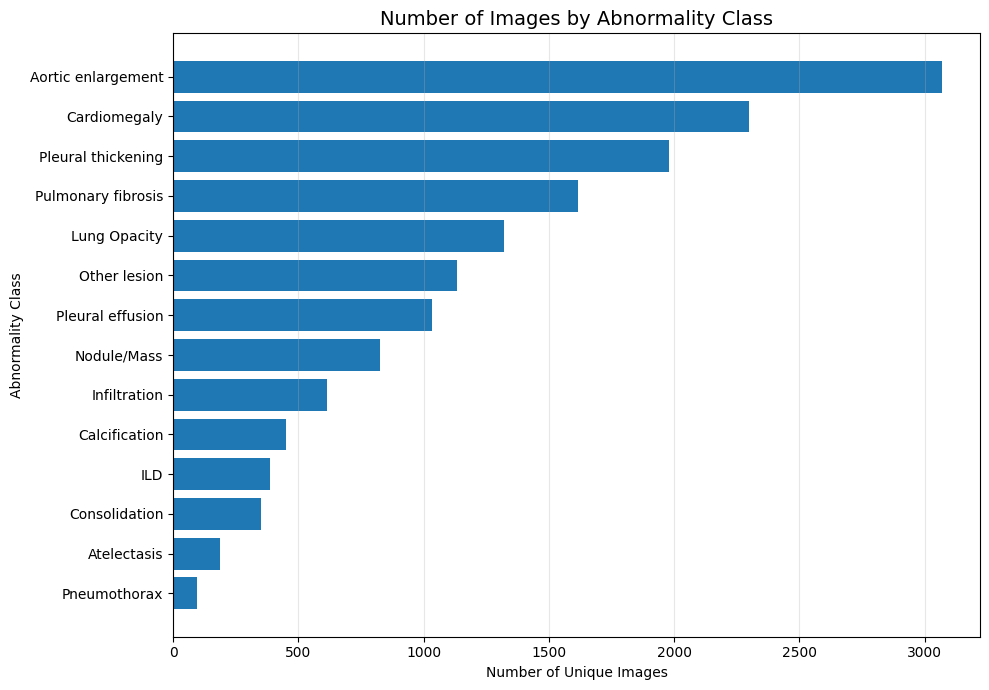

In [10]:
# ============================================================
# Step 4. Analyze the Dataset Distribution
# ============================================================
# 이 단계에서는 학습 데이터의 전체 구성을 확인합니다.
#
# 확인할 내용:
# - 전체 X-ray 이미지 수
# - 정상 이미지와 비정상 이미지 수
# - 병변 클래스별 이미지 수
# - 병변 클래스별 Bounding Box 수
#
# 클래스마다 데이터 수가 크게 다르면 모델이 데이터가 많은
# 병변은 잘 학습하고, 데이터가 적은 병변은 잘 학습하지 못할 수
# 있으므로 모델 학습 전에 반드시 분포를 확인해야 합니다.
#
# 주의:
# 같은 이미지를 여러 영상의학과 전문의가 판독했기 때문에
# 동일한 병변의 Bounding Box가 여러 행에 포함될 수 있습니다.
# 이 단계에서는 원본 분포만 확인하고, 중복 박스는 이후 정리합니다.
# ============================================================


# -----------------------------
# 1. 기본 설정
# -----------------------------
NO_FINDING_ID = 14
NO_FINDING_NAME = "No finding"

total_images = train_df["image_id"].nunique()


# -----------------------------
# 2. 정상·비정상 이미지 구분
# -----------------------------
# 하나라도 병변 Bounding Box가 있으면 비정상 이미지로 분류한다.
abnormal_image_ids = set(
    train_df.loc[
        train_df["class_id"] != NO_FINDING_ID,
        "image_id"
    ].unique()
)

# 비정상 병변이 하나도 없는 이미지를 정상 이미지로 분류한다.
all_image_ids = set(train_df["image_id"].unique())
normal_image_ids = all_image_ids - abnormal_image_ids

normal_images = len(normal_image_ids)
abnormal_images = len(abnormal_image_ids)

normal_ratio = normal_images / total_images * 100
abnormal_ratio = abnormal_images / total_images * 100


# -----------------------------
# 3. 병변 정보만 선택
# -----------------------------
# No finding은 Bounding Box가 없으므로 병변 분석에서 제외한다.
bbox_df = train_df[
    (train_df["class_id"] != NO_FINDING_ID)
    & train_df["x_min"].notna()
    & train_df["y_min"].notna()
    & train_df["x_max"].notna()
    & train_df["y_max"].notna()
].copy()


# -----------------------------
# 4. 클래스별 이미지 수 계산
# -----------------------------
class_image_counts = (
    bbox_df
    .groupby(["class_id", "class_name"])["image_id"]
    .nunique()
    .reset_index(name="image_count")
)


# -----------------------------
# 5. 클래스별 Bounding Box 수 계산
# -----------------------------
class_bbox_counts = (
    bbox_df
    .groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="bbox_count")
)


# -----------------------------
# 6. 클래스별 분포 표 만들기
# -----------------------------
class_distribution_df = (
    class_image_counts
    .merge(
        class_bbox_counts,
        on=["class_id", "class_name"],
        how="left"
    )
    .sort_values(
        by="image_count",
        ascending=False
    )
    .reset_index(drop=True)
)

class_distribution_df["image_ratio_percent"] = (
    class_distribution_df["image_count"]
    / total_images
    * 100
).round(2)


# -----------------------------
# 7. 전체 데이터 요약 출력
# -----------------------------
print("=" * 60)
print("Dataset Distribution Summary")
print("=" * 60)

print(f"Total X-ray images    : {total_images:,}")
print(
    f"Normal images         : "
    f"{normal_images:,} ({normal_ratio:.2f}%)"
)
print(
    f"Abnormal images       : "
    f"{abnormal_images:,} ({abnormal_ratio:.2f}%)"
)
print(f"Abnormality classes   : {bbox_df['class_id'].nunique()}")
print(f"Bounding Box rows     : {len(bbox_df):,}")

print("=" * 60)


# -----------------------------
# 8. 클래스별 분포 표 출력
# -----------------------------
display(class_distribution_df)


# -----------------------------
# 9. 클래스별 이미지 수 시각화
# -----------------------------
plot_df = class_distribution_df.sort_values(
    by="image_count",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["class_name"],
    plot_df["image_count"]
)

plt.title(
    "Number of Images by Abnormality Class",
    fontsize=14
)
plt.xlabel("Number of Unique Images")
plt.ylabel("Abnormality Class")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

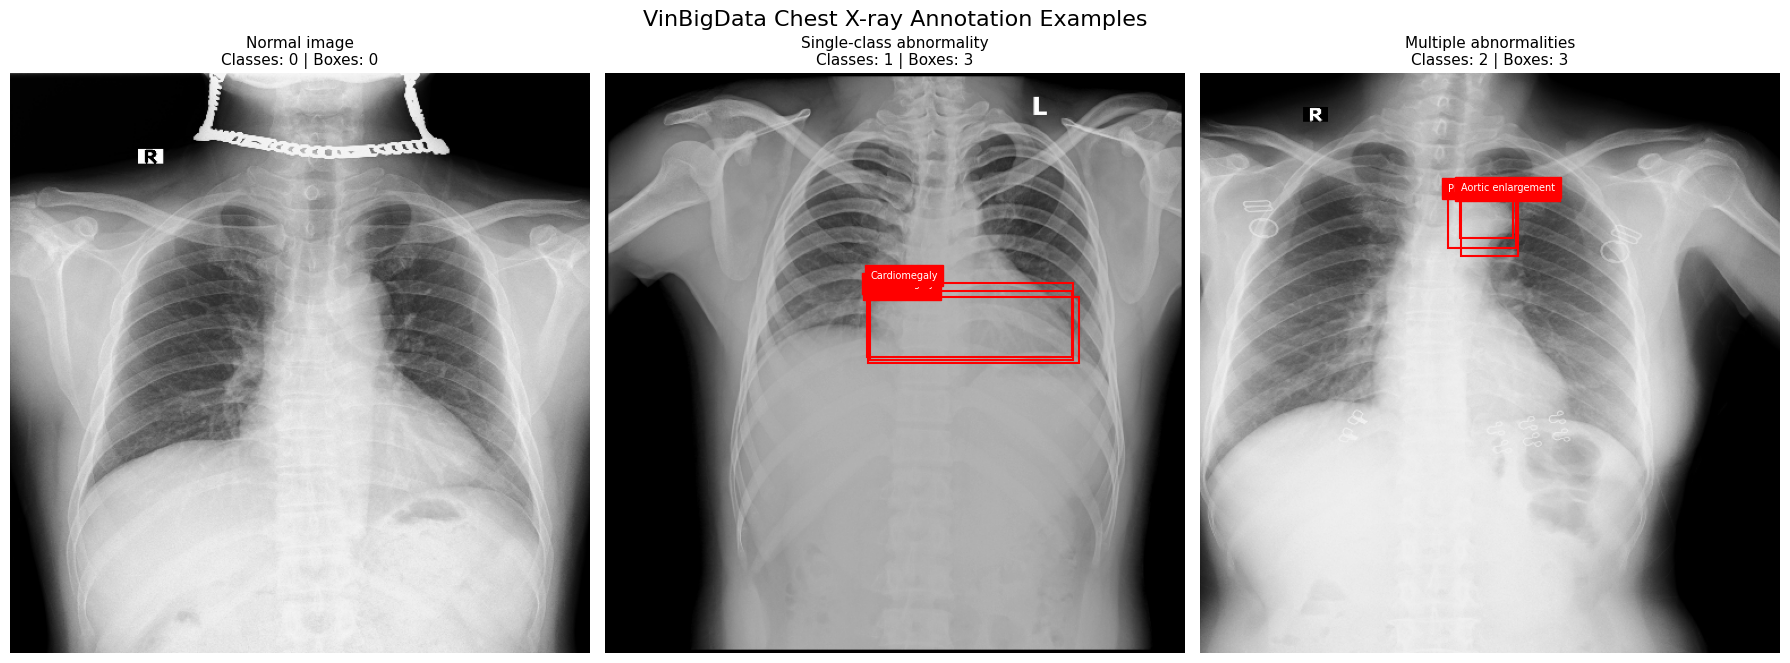

,sample_type,image_id
0,Normal image,000434271f63a053c4128a0ba6352c7f
1,Single-class abnormality,011244ab511b20130d846f5f8f0c3866
2,Multiple abnormalities,014e3dd712dc90f61da7ce8747d8c4c0


In [11]:
# ============================================================
# Step 5. Visualize X-ray Images and Bounding Boxes
# ============================================================
# 이 단계에서는 실제 흉부 X-ray 이미지와 병변 위치를
# Bounding Box로 표시하여 눈으로 확인합니다.
#
# 확인할 이미지:
# - 정상 이미지 1장
# - 한 종류의 병변이 있는 이미지 1장
# - 여러 종류의 병변이 있는 이미지 1장
#
# CSV의 Bounding Box 좌표가 실제 이미지의 병변 위치와
# 올바르게 연결되어 있는지 확인하기 위해 수행합니다.
#
# 여러 영상의학과 전문의가 같은 병변을 표시했기 때문에
# 비슷한 위치에 여러 박스가 겹쳐 보일 수 있습니다.
# ============================================================


# -----------------------------
# 1. 필요한 라이브러리
# -----------------------------
import matplotlib.patches as patches


# -----------------------------
# 2. 이미지 ID와 파일 경로 연결
# -----------------------------
image_path_dict = {
    path.stem: path
    for path in train_image_paths
}


# -----------------------------
# 3. 이미지별 병변 정보 계산
# -----------------------------
image_annotation_summary = (
    bbox_df
    .groupby("image_id")
    .agg(
        class_count=("class_id", "nunique"),
        bbox_count=("class_id", "size")
    )
    .reset_index()
)


# -----------------------------
# 4. 확인할 이미지 선택
# -----------------------------

# 정상 이미지 1장
normal_image_id = sorted(normal_image_ids)[0]


# 한 종류의 병변만 있는 이미지 중 박스 수가 적은 이미지
single_class_candidates = image_annotation_summary[
    (image_annotation_summary["class_count"] == 1)
    & (image_annotation_summary["bbox_count"] <= 3)
]

if len(single_class_candidates) == 0:
    single_class_candidates = image_annotation_summary[
        image_annotation_summary["class_count"] == 1
    ]

single_class_image_id = (
    single_class_candidates
    .sort_values(["bbox_count", "image_id"])
    .iloc[0]["image_id"]
)


# 두 종류 이상의 병변이 있는 이미지
multi_class_candidates = image_annotation_summary[
    (image_annotation_summary["class_count"] >= 2)
    & (image_annotation_summary["bbox_count"] <= 8)
]

if len(multi_class_candidates) == 0:
    multi_class_candidates = image_annotation_summary[
        image_annotation_summary["class_count"] >= 2
    ]

multi_class_image_id = (
    multi_class_candidates
    .sort_values(["class_count", "bbox_count", "image_id"])
    .iloc[0]["image_id"]
)


selected_samples = [
    ("Normal image", normal_image_id),
    ("Single-class abnormality", single_class_image_id),
    ("Multiple abnormalities", multi_class_image_id)
]


# -----------------------------
# 5. 이미지와 Bounding Box를 그리는 함수
# -----------------------------
def show_xray_with_boxes(ax, image_id, title):
    """
    X-ray 이미지를 불러오고,
    CSV에 저장된 Bounding Box를 이미지 위에 표시합니다.
    """

    image_path = image_path_dict.get(image_id)

    if image_path is None:
        ax.set_title(f"{title}\nImage not found")
        ax.axis("off")
        return

    image = cv2.imread(str(image_path))

    if image is None:
        ax.set_title(f"{title}\nFailed to load image")
        ax.axis("off")
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    displayed_height, displayed_width = image.shape[:2]

    ax.imshow(image)


    # 해당 이미지의 병변 정보
    image_boxes = bbox_df[
        bbox_df["image_id"] == image_id
    ].copy()


    for _, row in image_boxes.iterrows():

        # 원본 이미지 좌표를 현재 512 이미지 크기로 변환
        scale_x = displayed_width / row["width"]
        scale_y = displayed_height / row["height"]

        x_min = row["x_min"] * scale_x
        y_min = row["y_min"] * scale_y
        x_max = row["x_max"] * scale_x
        y_max = row["y_max"] * scale_y

        box_width = x_max - x_min
        box_height = y_max - y_min


        # Bounding Box 표시
        rectangle = patches.Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            linewidth=1.5,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)


        # 병변 이름 표시
        ax.text(
            x_min,
            max(y_min - 4, 0),
            row["class_name"],
            fontsize=7,
            color="white",
            backgroundcolor="red"
        )


    ax.set_title(
        f"{title}\n"
        f"Classes: {image_boxes['class_id'].nunique()} | "
        f"Boxes: {len(image_boxes)}",
        fontsize=11
    )

    ax.axis("off")


# -----------------------------
# 6. 대표 이미지 3장 시각화
# -----------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

for ax, (sample_name, image_id) in zip(
    axes,
    selected_samples
):
    show_xray_with_boxes(
        ax=ax,
        image_id=image_id,
        title=sample_name
    )

plt.suptitle(
    "VinBigData Chest X-ray Annotation Examples",
    fontsize=16
)

plt.tight_layout()
plt.show()


# -----------------------------
# 7. 선택된 이미지 정보 출력
# -----------------------------
selected_sample_df = pd.DataFrame(
    selected_samples,
    columns=["sample_type", "image_id"]
)

display(selected_sample_df)

In [12]:
# ============================================================
# Step 6. Split the Dataset into Train and Validation Sets
# ============================================================
# 이 단계에서는 전체 15,000장의 X-ray 이미지를
# 학습용 Train 데이터와 성능 확인용 Validation 데이터로 나눕니다.
#
# 분할 비율:
# - Train: 80%
# - Validation: 20%
#
# 단순히 무작위로 나누면 데이터가 적은 희귀 병변이
# 한쪽에 몰릴 수 있습니다.
#
# 따라서 각 이미지에 어떤 병변이 포함되어 있는지를 기준으로
# 14개 병변과 정상 이미지의 비율이 두 데이터에 최대한
# 비슷하게 유지되도록 Multi-label Stratified Split을 사용합니다.
#
# 또한 동일한 X-ray가 Train과 Validation에 동시에 들어가지
# 않았는지 확인하여 데이터 누수를 방지합니다.
# ============================================================


# -----------------------------
# 1. Multi-label 분할 라이브러리 설치
# -----------------------------
!pip install -q iterative-stratification


# -----------------------------
# 2. 필요한 라이브러리 불러오기
# -----------------------------
from iterstrat.ml_stratifiers import (
    MultilabelStratifiedShuffleSplit
)


# -----------------------------
# 3. 이미지별 클래스 정보 만들기
# -----------------------------
# 전체 이미지 ID를 한 번씩만 정리한다.
image_label_df = pd.DataFrame({
    "image_id": sorted(train_df["image_id"].unique())
})


# 14개 병변 클래스와 정상 클래스를 포함한다.
ALL_CLASS_IDS = list(range(15))

for class_id in ALL_CLASS_IDS:
    image_label_df[f"class_{class_id}"] = 0


# 같은 이미지와 같은 클래스가 여러 번 있어도
# 클래스 존재 여부는 한 번만 기록한다.
unique_image_classes = (
    train_df[["image_id", "class_id"]]
    .drop_duplicates()
)


# 각 이미지가 가진 클래스를 1로 표시한다.
image_id_to_index = {
    image_id: index
    for index, image_id
    in enumerate(image_label_df["image_id"])
}

for row in unique_image_classes.itertuples(index=False):

    image_index = image_id_to_index[row.image_id]
    class_column = f"class_{int(row.class_id)}"

    image_label_df.loc[
        image_index,
        class_column
    ] = 1


# -----------------------------
# 4. 분할에 사용할 값 준비
# -----------------------------
X = image_label_df[["image_id"]].values

label_columns = [
    f"class_{class_id}"
    for class_id in ALL_CLASS_IDS
]

y = image_label_df[label_columns].values


# -----------------------------
# 5. Train 80%, Validation 20% 분할
# -----------------------------
splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_indices, val_indices = next(
    splitter.split(X, y)
)


train_image_ids = set(
    image_label_df.iloc[train_indices]["image_id"]
)

val_image_ids = set(
    image_label_df.iloc[val_indices]["image_id"]
)


# -----------------------------
# 6. 이미지별 분할 정보 저장
# -----------------------------
split_df = image_label_df[["image_id"]].copy()
split_df["split"] = "train"

split_df.loc[
    split_df["image_id"].isin(val_image_ids),
    "split"
] = "validation"


SPLIT_CSV_PATH = OUTPUT_DIR / "train_validation_split.csv"
split_df.to_csv(SPLIT_CSV_PATH, index=False)


# -----------------------------
# 7. 데이터 중복 여부 확인
# -----------------------------
overlap_image_ids = (
    train_image_ids.intersection(val_image_ids)
)


# -----------------------------
# 8. 클래스별 분포 비교
# -----------------------------
class_name_map = (
    train_df[["class_id", "class_name"]]
    .drop_duplicates()
    .set_index("class_id")["class_name"]
    .to_dict()
)


distribution_rows = []

for class_id in ALL_CLASS_IDS:

    class_column = f"class_{class_id}"

    train_count = int(
        image_label_df
        .iloc[train_indices][class_column]
        .sum()
    )

    val_count = int(
        image_label_df
        .iloc[val_indices][class_column]
        .sum()
    )

    train_ratio = (
        train_count / len(train_indices) * 100
    )

    val_ratio = (
        val_count / len(val_indices) * 100
    )

    distribution_rows.append({
        "class_id": class_id,
        "class_name": class_name_map[class_id],
        "train_count": train_count,
        "validation_count": val_count,
        "train_ratio_percent": round(train_ratio, 2),
        "validation_ratio_percent": round(val_ratio, 2),
        "ratio_difference": round(
            abs(train_ratio - val_ratio),
            2
        )
    })


split_distribution_df = pd.DataFrame(
    distribution_rows
)


# -----------------------------
# 9. 분할 결과 출력
# -----------------------------
print("=" * 60)
print("Train and Validation Split Result")
print("=" * 60)

print(f"Total images         : {len(image_label_df):,}")
print(
    f"Train images         : "
    f"{len(train_image_ids):,} "
    f"({len(train_image_ids) / len(image_label_df) * 100:.2f}%)"
)
print(
    f"Validation images    : "
    f"{len(val_image_ids):,} "
    f"({len(val_image_ids) / len(image_label_df) * 100:.2f}%)"
)
print(f"Overlapping images   : {len(overlap_image_ids)}")
print(f"Split file saved     : {SPLIT_CSV_PATH}")

print("=" * 60)


# -----------------------------
# 10. 클래스별 분포 표 확인
# -----------------------------
display(split_distribution_df)

Train and Validation Split Result
Total images         : 15,000
Train images         : 12,020 (80.13%)
Validation images    : 2,980 (19.87%)
Overlapping images   : 0
Split file saved     : /kaggle/working/vinbigdata_yolo/outputs/train_validation_split.csv


,class_id,class_name,train_count,validation_count,train_ratio_percent,validation_ratio_percent,ratio_difference
0,0,Aortic enlargement,2454,613,20.42,20.57,0.15
1,1,Atelectasis,149,37,1.24,1.24,0.00
2,2,Calcification,362,90,3.01,3.02,0.01
3,3,Cardiomegaly,1840,460,15.31,15.44,0.13
4,4,Consolidation,282,71,2.35,2.38,0.04
5,5,ILD,309,77,2.57,2.58,0.01
6,6,Infiltration,490,123,4.08,4.13,0.05
7,7,Lung Opacity,1058,264,8.80,8.86,0.06
8,8,Nodule/Mass,661,165,5.50,5.54,0.04
9,9,Other lesion,907,227,7.55,7.62,0.07


In [13]:
# ============================================================
# Step 7. Convert the Dataset to YOLO Format
# ============================================================
# 이 단계에서는 원본 CSV에 저장된 Bounding Box 좌표를
# YOLO가 학습할 수 있는 라벨 형식으로 변환합니다.
#
# 원본 Bounding Box 형식:
# x_min, y_min, x_max, y_max
#
# YOLO 라벨 형식:
# class_id, x_center, y_center, box_width, box_height
#
# YOLO의 좌표는 이미지 크기와 관계없이 사용할 수 있도록
# 모든 값을 0~1 범위로 정규화합니다.
#
# 정상 이미지에는 병변 Bounding Box가 없기 때문에
# 내용이 비어 있는 txt 라벨 파일을 생성합니다.
#
# Baseline 모델에서는 여러 판독의가 표시한 원본 Bounding Box를
# 정리하지 않고 그대로 사용합니다.
# 중복 Bounding Box 정리는 이후 Improvement 단계에서 수행합니다.
#
# 이미지 파일은 복사하지 않고 Symbolic Link로 연결하여
# 저장 공간과 데이터 준비 시간을 줄입니다.
# ============================================================


# -----------------------------
# 1. 필요한 라이브러리
# -----------------------------
import shutil
import yaml
from tqdm.auto import tqdm


# -----------------------------
# 2. Baseline 데이터 저장 경로
# -----------------------------
BASELINE_DATA_DIR = PROJECT_DIR / "baseline_dataset"

BASELINE_TRAIN_IMAGE_DIR = (
    BASELINE_DATA_DIR / "images" / "train"
)

BASELINE_VAL_IMAGE_DIR = (
    BASELINE_DATA_DIR / "images" / "val"
)

BASELINE_TRAIN_LABEL_DIR = (
    BASELINE_DATA_DIR / "labels" / "train"
)

BASELINE_VAL_LABEL_DIR = (
    BASELINE_DATA_DIR / "labels" / "val"
)


# 이전에 실행한 결과가 있다면 삭제하고 다시 만든다.
if BASELINE_DATA_DIR.exists():
    shutil.rmtree(BASELINE_DATA_DIR)


# 필요한 폴더 생성
for folder in [
    BASELINE_TRAIN_IMAGE_DIR,
    BASELINE_VAL_IMAGE_DIR,
    BASELINE_TRAIN_LABEL_DIR,
    BASELINE_VAL_LABEL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)


# -----------------------------
# 3. 14개 병변 클래스 이름 정리
# -----------------------------
# class_id 14인 No finding은 탐지 대상이 아니므로 제외한다.
NUM_CLASSES = 14

CLASS_NAMES = [
    class_name_map[class_id]
    for class_id in range(NUM_CLASSES)
]

print("YOLO detection classes:")

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id:2d}: {class_name}")


# -----------------------------
# 4. 이미지별 Bounding Box 묶기
# -----------------------------
# 병변이 있는 이미지의 Bounding Box만 이미지 ID별로 묶는다.
bbox_grouped = {
    image_id: group
    for image_id, group in bbox_df.groupby("image_id")
}


# -----------------------------
# 5. YOLO 라벨 한 줄을 만드는 함수
# -----------------------------
def convert_box_to_yolo(row):
    """
    원본 Bounding Box 좌표를 YOLO 형식으로 변환합니다.

    반환 형식:
    class_id x_center y_center box_width box_height
    """

    image_width = float(row["width"])
    image_height = float(row["height"])


    # 좌표가 원본 이미지 범위를 벗어나지 않도록 제한
    x_min = max(0.0, min(float(row["x_min"]), image_width))
    y_min = max(0.0, min(float(row["y_min"]), image_height))
    x_max = max(0.0, min(float(row["x_max"]), image_width))
    y_max = max(0.0, min(float(row["y_max"]), image_height))


    # 잘못된 크기의 박스는 사용하지 않는다.
    if x_max <= x_min or y_max <= y_min:
        return None


    # Bounding Box의 중심 좌표 계산
    x_center = ((x_min + x_max) / 2) / image_width
    y_center = ((y_min + y_max) / 2) / image_height


    # Bounding Box의 너비와 높이 계산
    box_width = (x_max - x_min) / image_width
    box_height = (y_max - y_min) / image_height


    class_id = int(row["class_id"])


    # 14개 병변 클래스만 사용
    if class_id < 0 or class_id >= NUM_CLASSES:
        return None


    return (
        f"{class_id} "
        f"{x_center:.6f} "
        f"{y_center:.6f} "
        f"{box_width:.6f} "
        f"{box_height:.6f}"
    )


# -----------------------------
# 6. 이미지 연결 및 라벨 파일 생성
# -----------------------------
conversion_stats = {
    "train_images": 0,
    "validation_images": 0,
    "train_boxes": 0,
    "validation_boxes": 0,
    "empty_labels": 0,
    "invalid_boxes": 0,
    "missing_images": 0
}


for row in tqdm(
    split_df.itertuples(index=False),
    total=len(split_df),
    desc="Creating YOLO dataset"
):

    image_id = row.image_id
    split_name = row.split


    # Train과 Validation 저장 폴더 선택
    if split_name == "train":

        destination_image_dir = (
            BASELINE_TRAIN_IMAGE_DIR
        )

        destination_label_dir = (
            BASELINE_TRAIN_LABEL_DIR
        )

        conversion_stats["train_images"] += 1

    else:

        destination_image_dir = (
            BASELINE_VAL_IMAGE_DIR
        )

        destination_label_dir = (
            BASELINE_VAL_LABEL_DIR
        )

        conversion_stats["validation_images"] += 1


    # 원본 이미지 경로 확인
    source_image_path = image_path_dict.get(image_id)

    if source_image_path is None:
        conversion_stats["missing_images"] += 1
        continue


    # 이미지 Symbolic Link 생성
    destination_image_path = (
        destination_image_dir / source_image_path.name
    )

    destination_image_path.symlink_to(
        source_image_path
    )


    # 이미지와 같은 이름의 txt 라벨 파일 경로
    label_path = (
        destination_label_dir / f"{image_id}.txt"
    )


    yolo_label_lines = []


    # 병변이 있는 이미지라면 Bounding Box 변환
    if image_id in bbox_grouped:

        image_boxes = bbox_grouped[image_id]

        for _, box_row in image_boxes.iterrows():

            yolo_label = convert_box_to_yolo(
                box_row
            )

            if yolo_label is None:
                conversion_stats["invalid_boxes"] += 1
                continue

            yolo_label_lines.append(yolo_label)


    # 정상 이미지라면 빈 라벨 파일이 생성된다.
    if len(yolo_label_lines) == 0:
        conversion_stats["empty_labels"] += 1


    # YOLO txt 라벨 파일 저장
    label_path.write_text(
        "\n".join(yolo_label_lines),
        encoding="utf-8"
    )


    # 분할별 Bounding Box 수 기록
    if split_name == "train":

        conversion_stats["train_boxes"] += (
            len(yolo_label_lines)
        )

    else:

        conversion_stats["validation_boxes"] += (
            len(yolo_label_lines)
        )


# -----------------------------
# 7. data.yaml 파일 생성
# -----------------------------
# YOLO가 이미지 경로와 클래스 이름을 알 수 있도록 설정한다.
BASELINE_DATA_YAML_PATH = (
    BASELINE_DATA_DIR / "data.yaml"
)

data_yaml = {
    "path": str(BASELINE_DATA_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": CLASS_NAMES
}

with open(
    BASELINE_DATA_YAML_PATH,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        data_yaml,
        file,
        sort_keys=False,
        allow_unicode=True
    )


# -----------------------------
# 8. 변환 결과 출력
# -----------------------------
print()
print("=" * 60)
print("YOLO Dataset Conversion Result")
print("=" * 60)

print(
    f"Train images         : "
    f"{conversion_stats['train_images']:,}"
)

print(
    f"Validation images    : "
    f"{conversion_stats['validation_images']:,}"
)

print(
    f"Train Bounding Boxes : "
    f"{conversion_stats['train_boxes']:,}"
)

print(
    f"Val Bounding Boxes   : "
    f"{conversion_stats['validation_boxes']:,}"
)

print(
    f"Empty label files    : "
    f"{conversion_stats['empty_labels']:,}"
)

print(
    f"Invalid Boxes skipped: "
    f"{conversion_stats['invalid_boxes']:,}"
)

print(
    f"Missing images       : "
    f"{conversion_stats['missing_images']:,}"
)

print(f"Dataset folder       : {BASELINE_DATA_DIR}")
print(f"data.yaml            : {BASELINE_DATA_YAML_PATH}")

print("=" * 60)


# -----------------------------
# 9. data.yaml 내용 확인
# -----------------------------
with open(
    BASELINE_DATA_YAML_PATH,
    "r",
    encoding="utf-8"
) as file:

    print(file.read())

YOLO detection classes:
 0: Aortic enlargement
 1: Atelectasis
 2: Calcification
 3: Cardiomegaly
 4: Consolidation
 5: ILD
 6: Infiltration
 7: Lung Opacity
 8: Nodule/Mass
 9: Other lesion
10: Pleural effusion
11: Pleural thickening
12: Pneumothorax
13: Pulmonary fibrosis


Creating YOLO dataset:   0%|          | 0/15000 [00:00<?, ?it/s]


YOLO Dataset Conversion Result
Train images         : 12,020
Validation images    : 2,980
Train Bounding Boxes : 28,839
Val Bounding Boxes   : 7,257
Empty label files    : 10,606
Invalid Boxes skipped: 0
Missing images       : 0
Dataset folder       : /kaggle/working/vinbigdata_yolo/baseline_dataset
data.yaml            : /kaggle/working/vinbigdata_yolo/baseline_dataset/data.yaml
path: /kaggle/working/vinbigdata_yolo/baseline_dataset
train: images/train
val: images/val
names:
- Aortic enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung Opacity
- Nodule/Mass
- Other lesion
- Pleural effusion
- Pleural thickening
- Pneumothorax
- Pulmonary fibrosis



In [14]:
# ============================================================
# Step 8. Validate the Converted YOLO Dataset
# ============================================================
# 이 단계에서는 Step 7에서 만든 YOLO 데이터가 올바른지
# 학습 전에 최종적으로 검사합니다.
#
# 확인할 내용:
# - 모든 이미지에 같은 이름의 라벨 파일이 있는지
# - 각 라벨이 5개의 값으로 구성되어 있는지
# - class_id가 0~13 범위인지
# - Bounding Box 좌표가 0~1 범위인지
# - 너비와 높이가 0보다 큰지
#
# 마지막으로 변환된 YOLO 좌표를 실제 X-ray 위에 다시 그려
# Bounding Box가 올바른 위치에 표시되는지 확인합니다.
# ============================================================


# -----------------------------
# 1. 이미지와 라벨 파일 목록
# -----------------------------
baseline_train_images = sorted(
    BASELINE_TRAIN_IMAGE_DIR.glob("*")
)

baseline_val_images = sorted(
    BASELINE_VAL_IMAGE_DIR.glob("*")
)

baseline_train_labels = sorted(
    BASELINE_TRAIN_LABEL_DIR.glob("*.txt")
)

baseline_val_labels = sorted(
    BASELINE_VAL_LABEL_DIR.glob("*.txt")
)


# -----------------------------
# 2. 이미지와 라벨 이름 비교
# -----------------------------
train_image_stems = {
    path.stem for path in baseline_train_images
}

train_label_stems = {
    path.stem for path in baseline_train_labels
}

val_image_stems = {
    path.stem for path in baseline_val_images
}

val_label_stems = {
    path.stem for path in baseline_val_labels
}


missing_train_labels = (
    train_image_stems - train_label_stems
)

missing_val_labels = (
    val_image_stems - val_label_stems
)

extra_train_labels = (
    train_label_stems - train_image_stems
)

extra_val_labels = (
    val_label_stems - val_image_stems
)


# -----------------------------
# 3. 라벨 한 개를 검사하는 함수
# -----------------------------
def validate_yolo_label_file(label_path):
    """
    YOLO 라벨 파일의 형식과 좌표 범위를 검사합니다.

    반환값:
    - box_count: 정상적으로 읽은 Bounding Box 수
    - errors: 발견된 오류 목록
    """

    text = label_path.read_text(
        encoding="utf-8"
    ).strip()

    # 정상 이미지는 빈 라벨 파일을 사용한다.
    if text == "":
        return 0, []

    errors = []
    box_count = 0

    for line_number, line in enumerate(
        text.splitlines(),
        start=1
    ):

        values = line.split()

        # YOLO 라벨은 반드시 5개의 값이어야 한다.
        if len(values) != 5:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"5개 값이 아님"
            )
            continue

        try:
            class_id = int(values[0])

            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])

        except ValueError:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"숫자 변환 오류"
            )
            continue


        # 클래스 번호 검사
        if not 0 <= class_id < NUM_CLASSES:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"class_id 범위 오류"
            )


        # 중심 좌표 검사
        if not 0.0 <= x_center <= 1.0:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"x_center 범위 오류"
            )

        if not 0.0 <= y_center <= 1.0:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"y_center 범위 오류"
            )


        # 박스 크기 검사
        if not 0.0 < box_width <= 1.0:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"box_width 범위 오류"
            )

        if not 0.0 < box_height <= 1.0:
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"box_height 범위 오류"
            )


        # 박스가 이미지 밖으로 벗어나는지 검사
        x_min = x_center - box_width / 2
        x_max = x_center + box_width / 2
        y_min = y_center - box_height / 2
        y_max = y_center + box_height / 2

        tolerance = 1e-5

        if (
            x_min < -tolerance
            or y_min < -tolerance
            or x_max > 1 + tolerance
            or y_max > 1 + tolerance
        ):
            errors.append(
                f"{label_path.name} "
                f"line {line_number}: "
                f"Bounding Box가 이미지 범위를 벗어남"
            )

        box_count += 1

    return box_count, errors


# -----------------------------
# 4. 전체 라벨 파일 검사
# -----------------------------
validation_results = {}

all_label_errors = []

for split_name, label_paths in [
    ("train", baseline_train_labels),
    ("validation", baseline_val_labels)
]:

    total_boxes = 0
    empty_label_count = 0
    split_errors = []

    for label_path in tqdm(
        label_paths,
        desc=f"Validating {split_name} labels"
    ):

        box_count, errors = (
            validate_yolo_label_file(label_path)
        )

        total_boxes += box_count

        if box_count == 0:
            empty_label_count += 1

        split_errors.extend(errors)

    validation_results[split_name] = {
        "image_count": (
            len(baseline_train_images)
            if split_name == "train"
            else len(baseline_val_images)
        ),
        "label_count": len(label_paths),
        "box_count": total_boxes,
        "empty_label_count": empty_label_count,
        "error_count": len(split_errors)
    }

    all_label_errors.extend(split_errors)


# -----------------------------
# 5. 검증 결과 표 만들기
# -----------------------------
dataset_validation_df = pd.DataFrame([
    {
        "split": "train",
        **validation_results["train"]
    },
    {
        "split": "validation",
        **validation_results["validation"]
    }
])

VALIDATION_CSV_PATH = (
    OUTPUT_DIR / "baseline_dataset_validation.csv"
)

dataset_validation_df.to_csv(
    VALIDATION_CSV_PATH,
    index=False
)


# -----------------------------
# 6. 전체 검증 결과 출력
# -----------------------------
print()
print("=" * 60)
print("YOLO Dataset Validation Result")
print("=" * 60)

print(
    f"Missing train labels : "
    f"{len(missing_train_labels)}"
)

print(
    f"Missing val labels   : "
    f"{len(missing_val_labels)}"
)

print(
    f"Extra train labels   : "
    f"{len(extra_train_labels)}"
)

print(
    f"Extra val labels     : "
    f"{len(extra_val_labels)}"
)

print(
    f"Invalid label errors : "
    f"{len(all_label_errors)}"
)

print(
    f"Validation CSV       : "
    f"{VALIDATION_CSV_PATH}"
)

print("=" * 60)

display(dataset_validation_df)


# 오류가 발견되면 일부 내용을 출력한다.
if all_label_errors:

    print("발견된 오류 예시:")

    for error in all_label_errors[:10]:
        print("-", error)

else:
    print("검증 완료: 모든 YOLO 라벨이 정상입니다.")

Validating train labels:   0%|          | 0/12020 [00:00<?, ?it/s]

Validating validation labels:   0%|          | 0/2980 [00:00<?, ?it/s]


YOLO Dataset Validation Result
Missing train labels : 0
Missing val labels   : 0
Extra train labels   : 0
Extra val labels     : 0
Invalid label errors : 0
Validation CSV       : /kaggle/working/vinbigdata_yolo/outputs/baseline_dataset_validation.csv


,split,image_count,label_count,box_count,empty_label_count,error_count
0,train,12020,12020,28839,8485,0
1,validation,2980,2980,7257,2121,0


검증 완료: 모든 YOLO 라벨이 정상입니다.


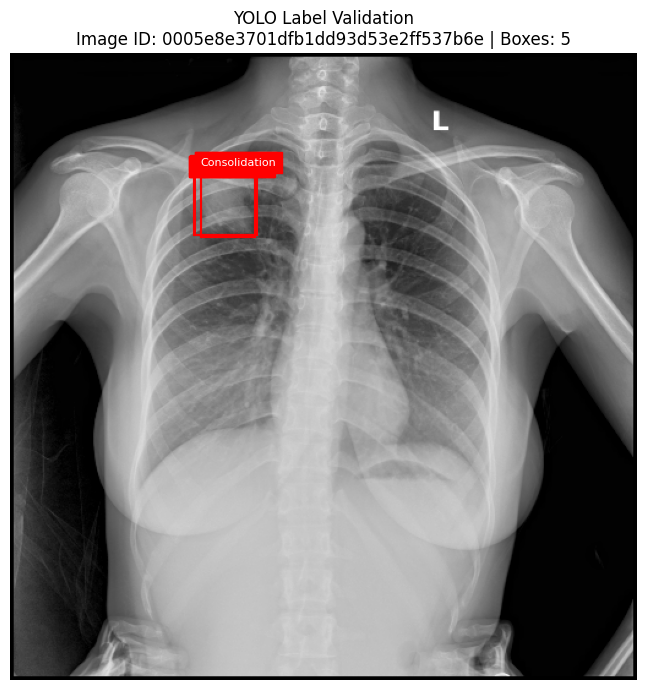

In [16]:
# -----------------------------
# 7. 변환된 YOLO 라벨 시각화
# -----------------------------
def show_yolo_label_sample(
    image_path,
    label_path
):
    """
    YOLO 형식의 정규화된 좌표를 다시 픽셀 좌표로 바꾸고,
    X-ray 이미지 위에 Bounding Box를 표시합니다.
    """

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image_height, image_width = image.shape[:2]

    label_text = label_path.read_text(
        encoding="utf-8"
    ).strip()

    plt.figure(figsize=(7, 7))
    plt.imshow(image)

    ax = plt.gca()
    box_count = 0

    if label_text:

        for line in label_text.splitlines():

            values = line.split()

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])


            # 정규화 좌표를 픽셀 좌표로 복원
            x_center_pixel = (
                x_center * image_width
            )

            y_center_pixel = (
                y_center * image_height
            )

            box_width_pixel = (
                box_width * image_width
            )

            box_height_pixel = (
                box_height * image_height
            )


            x_min = (
                x_center_pixel
                - box_width_pixel / 2
            )

            y_min = (
                y_center_pixel
                - box_height_pixel / 2
            )


            rectangle = patches.Rectangle(
                (x_min, y_min),
                box_width_pixel,
                box_height_pixel,
                linewidth=1.5,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rectangle)

            ax.text(
                x_min,
                max(y_min - 3, 0),
                CLASS_NAMES[class_id],
                fontsize=8,
                color="white",
                backgroundcolor="red"
            )

            box_count += 1


    plt.title(
        f"YOLO Label Validation\n"
        f"Image ID: {image_path.stem} | "
        f"Boxes: {box_count}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 8. Validation 이미지 한 장 선택
# -----------------------------
# Bounding Box가 1~5개인 이미지를 선택하여
# 너무 복잡하지 않은 예시를 확인한다.
sample_label_path = None

for label_path in baseline_val_labels:

    label_text = label_path.read_text(
        encoding="utf-8"
    ).strip()

    if not label_text:
        continue

    number_of_boxes = len(
        label_text.splitlines()
    )

    if 1 <= number_of_boxes <= 5:
        sample_label_path = label_path
        break


if sample_label_path is None:
    raise ValueError(
        "시각화할 Validation 라벨을 찾지 못했습니다."
    )


sample_image_path = next(
    path
    for path in baseline_val_images
    if path.stem == sample_label_path.stem
)


show_yolo_label_sample(
    image_path=sample_image_path,
    label_path=sample_label_path
)

In [17]:
# ============================================================
# Step 9. Train the YOLOv8s Baseline Model
# ============================================================
# 이 단계에서는 사전학습된 YOLOv8s 모델을 사용하여
# 흉부 X-ray 병변 탐지 Baseline 모델을 학습합니다.
#
# Baseline 모델은 이후 Improvement 모델의 성능이 실제로
# 좋아졌는지 비교하기 위한 기준 모델입니다.
#
# 주요 설정:
# - Model: YOLOv8s
# - Image size: 512 × 512
# - Maximum epochs: 30
# - Batch size: 16
# - Early Stopping patience: 7
# - GPU: Kaggle T4 × 2
#
# 의료영상의 구조가 부자연스럽게 변하지 않도록
# 상하·좌우 반전, Mosaic, MixUp은 사용하지 않습니다.
#
# Validation mAP50-95가 7번 연속 좋아지지 않으면
# 과적합과 불필요한 학습을 줄이기 위해 자동 종료합니다.
# ============================================================


# -----------------------------
# 1. Baseline 학습 결과 저장 경로
# -----------------------------
BASELINE_RUNS_DIR = PROJECT_DIR / "runs"
BASELINE_RUN_NAME = "yolov8s_baseline_512"

BASELINE_RUN_DIR = (
    BASELINE_RUNS_DIR / BASELINE_RUN_NAME
)


# 이전 실행 결과가 있다면 삭제하여
# 새로운 결과와 섞이지 않도록 한다.
if BASELINE_RUN_DIR.exists():
    shutil.rmtree(BASELINE_RUN_DIR)


# -----------------------------
# 2. 사전학습된 YOLOv8s 불러오기
# -----------------------------
baseline_model = YOLO("yolov8s.pt")


# -----------------------------
# 3. Baseline 모델 학습
# -----------------------------
baseline_train_results = baseline_model.train(

    # 학습 데이터 설정
    data=str(BASELINE_DATA_YAML_PATH),

    # 기본 학습 설정
    epochs=30,
    imgsz=512,
    batch=16,

    # Kaggle T4 GPU 2개 사용
    device=DEVICE,
    workers=2,

    # Early Stopping
    patience=7,

    # Optimizer 설정
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # 전이학습 및 AMP
    pretrained=True,
    amp=True,

    # 재현성 설정
    seed=SEED,
    deterministic=True,

    # 의료영상에 맞춘 약한 데이터 증강
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,

    degrees=3.0,
    translate=0.03,
    scale=0.10,

    shear=0.0,
    perspective=0.0,

    # 해부학적 좌우와 상하 방향 보존
    fliplr=0.0,
    flipud=0.0,

    # 의료영상에 부자연스러운 합성 증강 제외
    mosaic=0.0,
    mixup=0.0,

    # 학습 중 Validation 수행
    val=True,
    plots=True,

    # 모델과 결과 저장
    save=True,
    project=str(BASELINE_RUNS_DIR),
    name=BASELINE_RUN_NAME,
    exist_ok=True,

    # 데이터 캐시는 사용하지 않아
    # Kaggle 메모리 부족 가능성을 줄인다.
    cache=False,

    verbose=True
)


# -----------------------------
# 4. 학습 결과 파일 확인
# -----------------------------
BASELINE_BEST_MODEL_PATH = (
    BASELINE_RUN_DIR / "weights" / "best.pt"
)

BASELINE_LAST_MODEL_PATH = (
    BASELINE_RUN_DIR / "weights" / "last.pt"
)


print()
print("=" * 60)
print("Baseline Training Result")
print("=" * 60)

print(f"Training folder : {BASELINE_RUN_DIR}")
print(f"Best model      : {BASELINE_BEST_MODEL_PATH}")
print(f"Last model      : {BASELINE_LAST_MODEL_PATH}")

print(
    f"Best model saved: "
    f"{BASELINE_BEST_MODEL_PATH.exists()}"
)

print(
    f"Last model saved: "
    f"{BASELINE_LAST_MODEL_PATH.exists()}"
)

print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vinbigdata_yolo/baseline_dataset/data.yaml, degrees=3.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 96.4±21.1 MB/s, size: 126.8 KB)
val: Scanning /kaggle/working/vinbigdata_yolo/baseline_dataset/labels/val.cache... 2980 images, 2121 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2980/2980 833.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 187/187 7.0it/s 26.5s0.1ss
                   all       2980       7257       0.35      0.286      0.246      0.118
Speed: 0.6ms preprocess, 5.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/vinbigdata_yolo/runs/yolov8s_baseline_evaluation
Baseline Model Evaluation Result


,model,image_size,precision,recall,mAP50,mAP50_95
0,YOLOv8s Baseline,512,0.3498,0.2858,0.2456,0.1182



Class-wise Evaluation Result


,class_id,class_name,validation_images,validation_boxes,precision,recall,f1_score,mAP50,mAP50_95
0,0,Aortic enlargement,613,1395,0.6530,0.6179,0.6350,0.6220,0.3687
1,1,Atelectasis,37,62,0.2742,0.1935,0.2269,0.1419,0.0680
2,2,Calcification,90,177,0.2269,0.1751,0.1977,0.1207,0.0470
3,3,Cardiomegaly,460,1075,0.6945,0.5079,0.5867,0.5491,0.3568
4,4,Consolidation,71,120,0.3393,0.3167,0.3276,0.2573,0.1234
5,5,ILD,77,204,0.2586,0.3480,0.2967,0.2016,0.0858
6,6,Infiltration,123,261,0.3671,0.2666,0.3089,0.2401,0.0980
7,7,Lung Opacity,264,517,0.3284,0.2553,0.2873,0.2209,0.0859
8,8,Nodule/Mass,165,534,0.4734,0.1902,0.2714,0.2084,0.0912
9,9,Other lesion,227,417,0.1697,0.0983,0.1245,0.0609,0.0214


Overall metrics saved : /kaggle/working/vinbigdata_yolo/outputs/baseline_overall_metrics.csv
Class metrics saved   : /kaggle/working/vinbigdata_yolo/outputs/baseline_class_metrics.csv
Evaluation plots      : /kaggle/working/vinbigdata_yolo/runs/yolov8s_baseline_evaluation


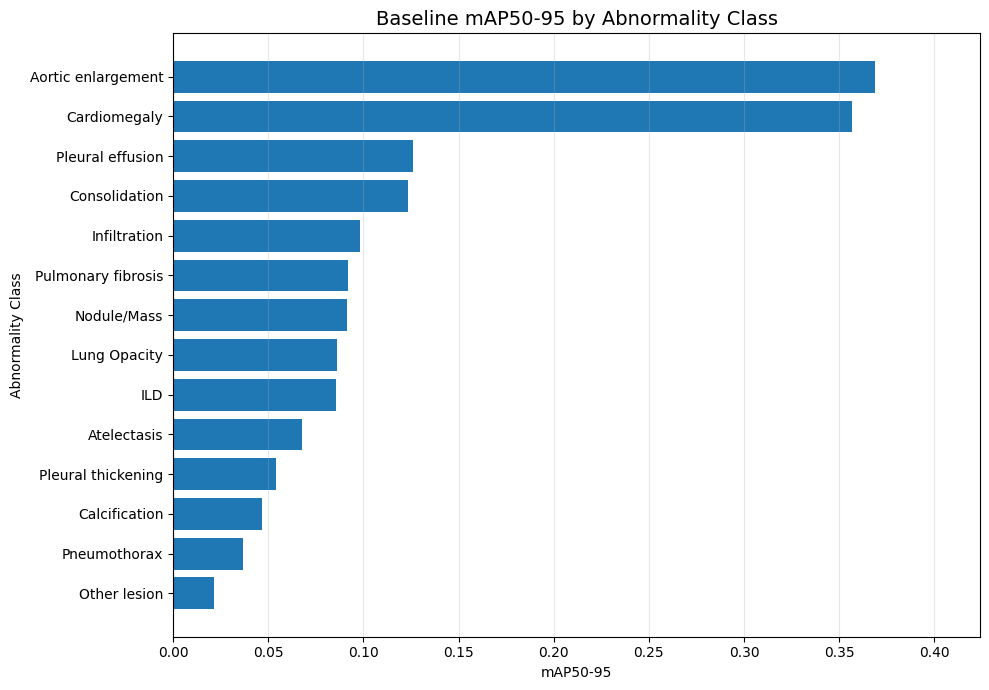

In [18]:
# ============================================================
# Step 10. Evaluate the YOLOv8s Baseline Model
# ============================================================
# 이 단계에서는 학습 과정에서 Validation 성능이 가장 좋았던
# best.pt 모델을 불러와 Baseline 성능을 최종 평가합니다.
#
# 확인할 평가 지표:
# - Precision: 모델이 병변이라고 예측한 결과 중 실제 병변의 비율
# - Recall: 실제 병변 중 모델이 찾아낸 비율
# - mAP50: IoU 0.5 기준의 평균 탐지 성능
# - mAP50-95: 여러 IoU 기준을 종합한 더 엄격한 탐지 성능
#
# 전체 평균 성능과 14개 병변별 성능을 각각 저장합니다.
# 이후 Improvement 모델과 같은 지표로 비교하기 위해 사용합니다.
# ============================================================


# -----------------------------
# 1. 평가 결과 저장 경로 설정
# -----------------------------
BASELINE_EVAL_NAME = "yolov8s_baseline_evaluation"

BASELINE_EVAL_DIR = (
    BASELINE_RUNS_DIR / BASELINE_EVAL_NAME
)

if BASELINE_EVAL_DIR.exists():
    shutil.rmtree(BASELINE_EVAL_DIR)


# -----------------------------
# 2. 가장 좋은 Baseline 모델 불러오기
# -----------------------------
baseline_best_model = YOLO(
    str(BASELINE_BEST_MODEL_PATH)
)


# -----------------------------
# 3. Validation 데이터로 최종 평가
# -----------------------------
# 학습과 동일한 이미지 크기 512를 사용합니다.
# 평가는 GPU 0번 하나만 사용해도 충분합니다.
baseline_val_metrics = baseline_best_model.val(
    data=str(BASELINE_DATA_YAML_PATH),
    split="val",

    imgsz=512,
    batch=16,

    device=0,
    workers=2,

    iou=0.7,
    max_det=300,

    plots=True,

    project=str(BASELINE_RUNS_DIR),
    name=BASELINE_EVAL_NAME,
    exist_ok=True,

    verbose=False
)


# -----------------------------
# 4. 전체 평균 성능 정리
# -----------------------------
baseline_overall_metrics_df = pd.DataFrame([
    {
        "model": "YOLOv8s Baseline",
        "image_size": 512,
        "precision": float(
            baseline_val_metrics.box.mp
        ),
        "recall": float(
            baseline_val_metrics.box.mr
        ),
        "mAP50": float(
            baseline_val_metrics.box.map50
        ),
        "mAP50_95": float(
            baseline_val_metrics.box.map
        )
    }
])


# 결과를 보기 좋게 소수점 4자리로 정리합니다.
baseline_overall_metrics_df[
    ["precision", "recall", "mAP50", "mAP50_95"]
] = baseline_overall_metrics_df[
    ["precision", "recall", "mAP50", "mAP50_95"]
].round(4)


# -----------------------------
# 5. 클래스별 성능 값 가져오기
# -----------------------------
def convert_to_numpy(value):
    """
    PyTorch Tensor 또는 배열을
    NumPy 배열로 변환하는 함수입니다.
    """

    if hasattr(value, "cpu"):
        value = value.cpu().numpy()

    return np.asarray(value)


box_metrics = baseline_val_metrics.box

class_ids = convert_to_numpy(
    box_metrics.ap_class_index
).astype(int)

precision_values = convert_to_numpy(
    box_metrics.p
).astype(float)

recall_values = convert_to_numpy(
    box_metrics.r
).astype(float)

map50_values = convert_to_numpy(
    box_metrics.ap50
).astype(float)

map50_95_values = convert_to_numpy(
    box_metrics.ap
).astype(float)


# -----------------------------
# 6. Validation 클래스별 데이터 수 계산
# -----------------------------
val_bbox_df = bbox_df[
    bbox_df["image_id"].isin(val_image_ids)
].copy()

val_class_image_counts = (
    val_bbox_df
    .groupby("class_id")["image_id"]
    .nunique()
    .to_dict()
)

val_class_box_counts = (
    val_bbox_df
    .groupby("class_id")
    .size()
    .to_dict()
)


# -----------------------------
# 7. 클래스별 성능 표 만들기
# -----------------------------
class_metric_rows = []

for index, class_id in enumerate(class_ids):

    precision = precision_values[index]
    recall = recall_values[index]

    # Precision과 Recall을 이용해 F1 Score 계산
    f1_score = (
        2 * precision * recall
        / (precision + recall + 1e-12)
    )

    class_metric_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],

        "validation_images": (
            val_class_image_counts.get(class_id, 0)
        ),

        "validation_boxes": (
            val_class_box_counts.get(class_id, 0)
        ),

        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "mAP50": map50_values[index],
        "mAP50_95": map50_95_values[index]
    })


baseline_class_metrics_df = pd.DataFrame(
    class_metric_rows
).sort_values(
    by="class_id"
).reset_index(drop=True)


metric_columns = [
    "precision",
    "recall",
    "f1_score",
    "mAP50",
    "mAP50_95"
]

baseline_class_metrics_df[metric_columns] = (
    baseline_class_metrics_df[metric_columns]
    .round(4)
)


# -----------------------------
# 8. 평가 결과 CSV 저장
# -----------------------------
BASELINE_OVERALL_CSV_PATH = (
    OUTPUT_DIR / "baseline_overall_metrics.csv"
)

BASELINE_CLASS_CSV_PATH = (
    OUTPUT_DIR / "baseline_class_metrics.csv"
)


baseline_overall_metrics_df.to_csv(
    BASELINE_OVERALL_CSV_PATH,
    index=False
)

baseline_class_metrics_df.to_csv(
    BASELINE_CLASS_CSV_PATH,
    index=False
)


# -----------------------------
# 9. 최종 결과 출력
# -----------------------------
print("=" * 60)
print("Baseline Model Evaluation Result")
print("=" * 60)

display(baseline_overall_metrics_df)

print()
print("Class-wise Evaluation Result")
display(baseline_class_metrics_df)

print(f"Overall metrics saved : {BASELINE_OVERALL_CSV_PATH}")
print(f"Class metrics saved   : {BASELINE_CLASS_CSV_PATH}")
print(f"Evaluation plots      : {BASELINE_EVAL_DIR}")

print("=" * 60)


# -----------------------------
# 10. 클래스별 mAP50-95 시각화
# -----------------------------
baseline_plot_df = (
    baseline_class_metrics_df
    .sort_values(
        by="mAP50_95",
        ascending=True
    )
)


plt.figure(figsize=(10, 7))

plt.barh(
    baseline_plot_df["class_name"],
    baseline_plot_df["mAP50_95"]
)

plt.title(
    "Baseline mAP50-95 by Abnormality Class",
    fontsize=14
)

plt.xlabel("mAP50-95")
plt.ylabel("Abnormality Class")

plt.xlim(
    0,
    max(
        baseline_plot_df["mAP50_95"].max() * 1.15,
        0.1
    )
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Step 11. Merge Overlapping Bounding Boxes
# ============================================================
# 이 단계에서는 여러 영상의학과 전문의가 같은 병변에 표시한
# 서로 비슷한 Bounding Box를 하나의 대표 박스로 통합합니다.
#
# 원본 데이터에서는 같은 병변에 대해 판독의마다 박스를
# 각각 표시했기 때문에 비슷한 위치의 박스가 여러 개 존재합니다.
#
# 처리 방법:
# 1. 같은 이미지와 같은 병변 클래스의 박스를 모읍니다.
# 2. 두 박스의 IoU가 0.5 이상이면 같은 병변으로 판단합니다.
# 3. 같은 그룹에 속한 박스 좌표의 평균을 계산합니다.
# 4. 서로 떨어진 병변의 박스는 별도로 유지합니다.
#
# 이를 통해 모델이 같은 병변을 여러 개의 객체로 잘못
# 학습할 가능성을 줄인 Improved Dataset을 준비합니다.
#
# 주의:
# 이것은 공식 정답 라벨이 아니라, 본 프로젝트에서 적용하는
# 간단한 IoU 기반 Annotation 정제 방법입니다.
# ============================================================


# -----------------------------
# 1. Bounding Box IoU 계산 함수
# -----------------------------
def calculate_box_iou(box_a, box_b):
    """
    두 Bounding Box가 얼마나 겹치는지 IoU를 계산합니다.

    box 형식:
    [x_min, y_min, x_max, y_max]
    """

    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    intersection_width = max(0.0, x_right - x_left)
    intersection_height = max(0.0, y_bottom - y_top)

    intersection_area = (
        intersection_width * intersection_height
    )

    box_a_area = (
        (box_a[2] - box_a[0])
        * (box_a[3] - box_a[1])
    )

    box_b_area = (
        (box_b[2] - box_b[0])
        * (box_b[3] - box_b[1])
    )

    union_area = (
        box_a_area
        + box_b_area
        - intersection_area
    )

    if union_area <= 0:
        return 0.0

    return intersection_area / union_area


# -----------------------------
# 2. 같은 클래스의 겹치는 박스를 합치는 함수
# -----------------------------
def merge_overlapping_boxes(
    group,
    iou_threshold=0.5
):
    """
    같은 이미지와 같은 클래스에 속한 박스 중
    IoU가 기준 이상인 박스를 하나의 그룹으로 묶습니다.

    각 그룹의 최종 박스는 좌표 평균으로 계산합니다.
    """

    group = group.reset_index(drop=True)

    boxes = group[
        ["x_min", "y_min", "x_max", "y_max"]
    ].astype(float).to_numpy()

    clusters = []


    # 박스를 하나씩 확인
    for box_index, box in enumerate(boxes):

        best_cluster_index = None
        best_iou = 0.0


        # 현재 박스와 기존 그룹의 대표 박스 비교
        for cluster_index, cluster in enumerate(
            clusters
        ):

            current_iou = calculate_box_iou(
                box,
                cluster["representative_box"]
            )

            if current_iou > best_iou:
                best_iou = current_iou
                best_cluster_index = cluster_index


        # IoU가 기준 이상이면 기존 그룹에 추가
        if (
            best_cluster_index is not None
            and best_iou >= iou_threshold
        ):

            clusters[
                best_cluster_index
            ]["box_indices"].append(box_index)

            cluster_indices = clusters[
                best_cluster_index
            ]["box_indices"]

            # 그룹에 포함된 박스 좌표 평균
            clusters[
                best_cluster_index
            ]["representative_box"] = (
                boxes[cluster_indices].mean(axis=0)
            )


        # 겹치는 그룹이 없으면 새로운 병변으로 등록
        else:

            clusters.append({
                "box_indices": [box_index],
                "representative_box": box.copy()
            })


    # 최종 통합 박스 정보 만들기
    merged_rows = []

    for cluster in clusters:

        cluster_indices = cluster["box_indices"]

        cluster_data = group.iloc[
            cluster_indices
        ]

        merged_box = (
            cluster_data[
                ["x_min", "y_min", "x_max", "y_max"]
            ]
            .astype(float)
            .mean()
        )

        merged_rows.append({
            "image_id": group.loc[0, "image_id"],
            "class_id": int(
                group.loc[0, "class_id"]
            ),
            "class_name": group.loc[
                0,
                "class_name"
            ],

            "x_min": merged_box["x_min"],
            "y_min": merged_box["y_min"],
            "x_max": merged_box["x_max"],
            "y_max": merged_box["y_max"],

            "width": int(group.loc[0, "width"]),
            "height": int(group.loc[0, "height"]),

            # 몇 개의 원본 박스가 합쳐졌는지 기록
            "annotation_count": len(
                cluster_indices
            ),

            # 몇 명의 판독의가 참여했는지 기록
            "radiologist_count": (
                cluster_data["rad_id"].nunique()
            )
        })

    return merged_rows


# -----------------------------
# 3. 전체 이미지의 중복 박스 통합
# -----------------------------
IOU_MERGE_THRESHOLD = 0.5

merged_annotation_rows = []


grouped_annotations = bbox_df.groupby(
    [
        "image_id",
        "class_id",
        "class_name"
    ],
    sort=False
)


for _, annotation_group in tqdm(
    grouped_annotations,
    total=grouped_annotations.ngroups,
    desc="Merging overlapping boxes"
):

    merged_rows = merge_overlapping_boxes(
        annotation_group,
        iou_threshold=IOU_MERGE_THRESHOLD
    )

    merged_annotation_rows.extend(
        merged_rows
    )


# -----------------------------
# 4. 통합된 Annotation DataFrame 생성
# -----------------------------
consensus_bbox_df = pd.DataFrame(
    merged_annotation_rows
)

consensus_bbox_df = (
    consensus_bbox_df
    .sort_values(
        ["image_id", "class_id"]
    )
    .reset_index(drop=True)
)


# -----------------------------
# 5. 결과 저장
# -----------------------------
CONSENSUS_BBOX_CSV_PATH = (
    OUTPUT_DIR / "consensus_bounding_boxes.csv"
)

consensus_bbox_df.to_csv(
    CONSENSUS_BBOX_CSV_PATH,
    index=False
)


# -----------------------------
# 6. 통합 전후 결과 비교
# -----------------------------
original_box_count = len(bbox_df)
merged_box_count = len(consensus_bbox_df)

removed_box_count = (
    original_box_count - merged_box_count
)

reduction_ratio = (
    removed_box_count
    / original_box_count
    * 100
)


merge_summary_df = pd.DataFrame([
    {
        "annotation_type": "Original annotations",
        "bounding_box_count": original_box_count
    },
    {
        "annotation_type": "Merged annotations",
        "bounding_box_count": merged_box_count
    }
])


print("=" * 60)
print("Bounding Box Merging Result")
print("=" * 60)

print(
    f"IoU threshold       : "
    f"{IOU_MERGE_THRESHOLD}"
)

print(
    f"Original boxes      : "
    f"{original_box_count:,}"
)

print(
    f"Merged boxes        : "
    f"{merged_box_count:,}"
)

print(
    f"Reduced boxes       : "
    f"{removed_box_count:,}"
)

print(
    f"Reduction ratio     : "
    f"{reduction_ratio:.2f}%"
)

print(
    f"Images with lesions : "
    f"{consensus_bbox_df['image_id'].nunique():,}"
)

print(
    f"Saved CSV           : "
    f"{CONSENSUS_BBOX_CSV_PATH}"
)

print("=" * 60)

display(merge_summary_df)


# -----------------------------
# 7. 박스 통합 수 분포 확인
# -----------------------------
annotation_merge_distribution = (
    consensus_bbox_df["annotation_count"]
    .value_counts()
    .sort_index()
    .rename_axis("merged_annotation_count")
    .reset_index(name="final_box_count")
)

display(annotation_merge_distribution)

Merging overlapping boxes:   0%|          | 0/15365 [00:00<?, ?it/s]

Bounding Box Merging Result
IoU threshold       : 0.5
Original boxes      : 36,096
Merged boxes        : 23,940
Reduced boxes       : 12,156
Reduction ratio     : 33.68%
Images with lesions : 4,394
Saved CSV           : /kaggle/working/vinbigdata_yolo/outputs/consensus_bounding_boxes.csv


,annotation_type,bounding_box_count
0,Original annotations,36096
1,Merged annotations,23940


,merged_annotation_count,final_box_count
0,1,15777
1,2,4171
2,3,3991
3,4,1


In [20]:
# ============================================================
# Step 12. Create the Improved YOLO Dataset
# ============================================================
# 이 단계에서는 Step 11에서 정리한 통합 Bounding Box를 사용해
# Improved 모델용 YOLO 데이터셋을 생성합니다.
#
# Baseline 데이터셋과의 차이:
# - Baseline: 판독의들이 표시한 원본 Bounding Box를 모두 사용
# - Improved: 많이 겹치는 Bounding Box를 대표 박스로 통합
#
# 모델을 공정하게 비교하기 위해 다음 조건은 동일하게 유지합니다.
# - 동일한 Train 이미지
# - 동일한 Validation 이미지
# - 동일한 14개 병변 클래스
#
# 정상 이미지는 Baseline과 마찬가지로 빈 txt 라벨 파일을 만듭니다.
# 이미지 파일은 복사하지 않고 Symbolic Link로 연결합니다.
# ============================================================


# -----------------------------
# 1. Improved 데이터 저장 경로 설정
# -----------------------------
IMPROVED_DATA_DIR = PROJECT_DIR / "improved_dataset"

IMPROVED_TRAIN_IMAGE_DIR = (
    IMPROVED_DATA_DIR / "images" / "train"
)

IMPROVED_VAL_IMAGE_DIR = (
    IMPROVED_DATA_DIR / "images" / "val"
)

IMPROVED_TRAIN_LABEL_DIR = (
    IMPROVED_DATA_DIR / "labels" / "train"
)

IMPROVED_VAL_LABEL_DIR = (
    IMPROVED_DATA_DIR / "labels" / "val"
)


# 이전 실행 결과가 있다면 삭제한다.
if IMPROVED_DATA_DIR.exists():
    shutil.rmtree(IMPROVED_DATA_DIR)


# 필요한 폴더를 생성한다.
for folder in [
    IMPROVED_TRAIN_IMAGE_DIR,
    IMPROVED_VAL_IMAGE_DIR,
    IMPROVED_TRAIN_LABEL_DIR,
    IMPROVED_VAL_LABEL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)


# -----------------------------
# 2. 통합 Bounding Box를 이미지별로 묶기
# -----------------------------
consensus_bbox_grouped = {
    image_id: group
    for image_id, group
    in consensus_bbox_df.groupby("image_id")
}


# -----------------------------
# 3. 변환 결과 기록 변수
# -----------------------------
improved_conversion_stats = {
    "train_images": 0,
    "validation_images": 0,
    "train_boxes": 0,
    "validation_boxes": 0,
    "empty_labels": 0,
    "invalid_boxes": 0,
    "missing_images": 0
}


# -----------------------------
# 4. 이미지 연결 및 YOLO 라벨 생성
# -----------------------------
for row in tqdm(
    split_df.itertuples(index=False),
    total=len(split_df),
    desc="Creating Improved YOLO dataset"
):

    image_id = row.image_id
    split_name = row.split


    # Train과 Validation 저장 경로 선택
    if split_name == "train":

        destination_image_dir = (
            IMPROVED_TRAIN_IMAGE_DIR
        )

        destination_label_dir = (
            IMPROVED_TRAIN_LABEL_DIR
        )

        improved_conversion_stats[
            "train_images"
        ] += 1

    else:

        destination_image_dir = (
            IMPROVED_VAL_IMAGE_DIR
        )

        destination_label_dir = (
            IMPROVED_VAL_LABEL_DIR
        )

        improved_conversion_stats[
            "validation_images"
        ] += 1


    # 원본 이미지 경로 확인
    source_image_path = image_path_dict.get(
        image_id
    )

    if source_image_path is None:

        improved_conversion_stats[
            "missing_images"
        ] += 1

        continue


    # 이미지 Symbolic Link 생성
    destination_image_path = (
        destination_image_dir
        / source_image_path.name
    )

    destination_image_path.symlink_to(
        source_image_path
    )


    # 이미지와 같은 이름의 라벨 파일 경로
    label_path = (
        destination_label_dir
        / f"{image_id}.txt"
    )


    yolo_label_lines = []


    # 병변이 있는 이미지라면
    # 통합된 Bounding Box를 YOLO 형식으로 변환
    if image_id in consensus_bbox_grouped:

        image_boxes = consensus_bbox_grouped[
            image_id
        ]

        for _, box_row in image_boxes.iterrows():

            yolo_label = convert_box_to_yolo(
                box_row
            )

            if yolo_label is None:

                improved_conversion_stats[
                    "invalid_boxes"
                ] += 1

                continue

            yolo_label_lines.append(
                yolo_label
            )


    # 정상 이미지는 빈 라벨 파일을 사용한다.
    if len(yolo_label_lines) == 0:

        improved_conversion_stats[
            "empty_labels"
        ] += 1


    # YOLO 라벨 파일 저장
    label_path.write_text(
        "\n".join(yolo_label_lines),
        encoding="utf-8"
    )


    # 분할별 Bounding Box 수 기록
    if split_name == "train":

        improved_conversion_stats[
            "train_boxes"
        ] += len(yolo_label_lines)

    else:

        improved_conversion_stats[
            "validation_boxes"
        ] += len(yolo_label_lines)


# -----------------------------
# 5. Improved data.yaml 생성
# -----------------------------
IMPROVED_DATA_YAML_PATH = (
    IMPROVED_DATA_DIR / "data.yaml"
)

improved_data_yaml = {
    "path": str(IMPROVED_DATA_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": CLASS_NAMES
}


with open(
    IMPROVED_DATA_YAML_PATH,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        improved_data_yaml,
        file,
        sort_keys=False,
        allow_unicode=True
    )


# -----------------------------
# 6. Baseline과 Improved 박스 수 비교
# -----------------------------
dataset_box_comparison_df = pd.DataFrame([
    {
        "dataset": "Baseline",
        "train_boxes": (
            conversion_stats["train_boxes"]
        ),
        "validation_boxes": (
            conversion_stats["validation_boxes"]
        ),
        "total_boxes": (
            conversion_stats["train_boxes"]
            + conversion_stats["validation_boxes"]
        )
    },
    {
        "dataset": "Improved",
        "train_boxes": (
            improved_conversion_stats["train_boxes"]
        ),
        "validation_boxes": (
            improved_conversion_stats[
                "validation_boxes"
            ]
        ),
        "total_boxes": (
            improved_conversion_stats["train_boxes"]
            + improved_conversion_stats[
                "validation_boxes"
            ]
        )
    }
])


# -----------------------------
# 7. 변환 결과 확인
# -----------------------------
print()
print("=" * 60)
print("Improved YOLO Dataset Creation Result")
print("=" * 60)

print(
    f"Train images         : "
    f"{improved_conversion_stats['train_images']:,}"
)

print(
    f"Validation images    : "
    f"{improved_conversion_stats['validation_images']:,}"
)

print(
    f"Train Bounding Boxes : "
    f"{improved_conversion_stats['train_boxes']:,}"
)

print(
    f"Val Bounding Boxes   : "
    f"{improved_conversion_stats['validation_boxes']:,}"
)

print(
    f"Total Bounding Boxes : "
    f"{improved_conversion_stats['train_boxes'] + improved_conversion_stats['validation_boxes']:,}"
)

print(
    f"Empty label files    : "
    f"{improved_conversion_stats['empty_labels']:,}"
)

print(
    f"Invalid Boxes skipped: "
    f"{improved_conversion_stats['invalid_boxes']:,}"
)

print(
    f"Missing images       : "
    f"{improved_conversion_stats['missing_images']:,}"
)

print(
    f"Dataset folder       : "
    f"{IMPROVED_DATA_DIR}"
)

print(
    f"data.yaml            : "
    f"{IMPROVED_DATA_YAML_PATH}"
)

print("=" * 60)


# -----------------------------
# 8. 데이터셋 비교 표 출력
# -----------------------------
display(dataset_box_comparison_df)


# -----------------------------
# 9. data.yaml 내용 확인
# -----------------------------
with open(
    IMPROVED_DATA_YAML_PATH,
    "r",
    encoding="utf-8"
) as file:

    print(file.read())


# -----------------------------
# 10. 핵심 결과 자동 확인
# -----------------------------
improved_total_boxes = (
    improved_conversion_stats["train_boxes"]
    + improved_conversion_stats[
        "validation_boxes"
    ]
)

assert improved_total_boxes == len(
    consensus_bbox_df
), "통합 박스 수와 YOLO 라벨 수가 일치하지 않습니다."

assert (
    improved_conversion_stats["missing_images"] == 0
), "누락된 이미지가 있습니다."

assert (
    improved_conversion_stats["invalid_boxes"] == 0
), "잘못된 Bounding Box가 있습니다."

print(
    "확인 완료: Improved 데이터셋이 정상적으로 생성되었습니다."
)

Creating Improved YOLO dataset:   0%|          | 0/15000 [00:00<?, ?it/s]


Improved YOLO Dataset Creation Result
Train images         : 12,020
Validation images    : 2,980
Train Bounding Boxes : 19,093
Val Bounding Boxes   : 4,847
Total Bounding Boxes : 23,940
Empty label files    : 10,606
Invalid Boxes skipped: 0
Missing images       : 0
Dataset folder       : /kaggle/working/vinbigdata_yolo/improved_dataset
data.yaml            : /kaggle/working/vinbigdata_yolo/improved_dataset/data.yaml


,dataset,train_boxes,validation_boxes,total_boxes
0,Baseline,28839,7257,36096
1,Improved,19093,4847,23940


path: /kaggle/working/vinbigdata_yolo/improved_dataset
train: images/train
val: images/val
names:
- Aortic enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung Opacity
- Nodule/Mass
- Other lesion
- Pleural effusion
- Pleural thickening
- Pneumothorax
- Pulmonary fibrosis

확인 완료: Improved 데이터셋이 정상적으로 생성되었습니다.


In [21]:
# ============================================================
# Step 13. Re-evaluate the Baseline Model
#          on the Consensus Validation Dataset
# ============================================================
# 이 단계에서는 기존 Baseline best.pt 모델을 다시 학습하지 않고,
# 통합된 Bounding Box가 적용된 Validation 데이터로 재평가합니다.
#
# 이 과정이 필요한 이유:
# - 기존 Baseline 평가: 원본 Validation Bounding Box 사용
# - Improved 평가: 통합된 Validation Bounding Box 사용 예정
#
# 서로 다른 정답 라벨로 계산한 mAP는 공정하게 비교할 수 없습니다.
# 따라서 Baseline과 Improved 모델 모두 동일한 통합 Validation
# 라벨을 기준으로 평가하도록 맞춥니다.
#
# Baseline 모델은 학습 당시와 동일하게 이미지 크기 512로 평가합니다.
# ============================================================


# -----------------------------
# 1. 평가 결과 저장 경로 설정
# -----------------------------
BASELINE_CONSENSUS_EVAL_NAME = (
    "yolov8s_baseline_consensus_evaluation"
)

BASELINE_CONSENSUS_EVAL_DIR = (
    BASELINE_RUNS_DIR
    / BASELINE_CONSENSUS_EVAL_NAME
)


if BASELINE_CONSENSUS_EVAL_DIR.exists():
    shutil.rmtree(
        BASELINE_CONSENSUS_EVAL_DIR
    )


# -----------------------------
# 2. 기존 Baseline best.pt 모델 불러오기
# -----------------------------
baseline_consensus_model = YOLO(
    str(BASELINE_BEST_MODEL_PATH)
)


# -----------------------------
# 3. 통합 Validation 라벨로 재평가
# -----------------------------
baseline_consensus_metrics = (
    baseline_consensus_model.val(

        # 통합된 Bounding Box를 사용하는 데이터
        data=str(IMPROVED_DATA_YAML_PATH),
        split="val",

        # Baseline 학습 조건과 동일한 이미지 크기
        imgsz=512,
        batch=16,

        device=0,
        workers=2,

        iou=0.7,
        max_det=300,

        plots=True,

        project=str(BASELINE_RUNS_DIR),
        name=BASELINE_CONSENSUS_EVAL_NAME,
        exist_ok=True,

        verbose=False
    )
)


# -----------------------------
# 4. 전체 성능 정리
# -----------------------------
baseline_consensus_overall_df = pd.DataFrame([
    {
        "model": "YOLOv8s Baseline",
        "training_labels": "Original",
        "evaluation_labels": "Consensus",
        "image_size": 512,

        "precision": float(
            baseline_consensus_metrics.box.mp
        ),

        "recall": float(
            baseline_consensus_metrics.box.mr
        ),

        "mAP50": float(
            baseline_consensus_metrics.box.map50
        ),

        "mAP50_95": float(
            baseline_consensus_metrics.box.map
        )
    }
])


metric_columns = [
    "precision",
    "recall",
    "mAP50",
    "mAP50_95"
]


baseline_consensus_overall_df[
    metric_columns
] = baseline_consensus_overall_df[
    metric_columns
].round(4)


# -----------------------------
# 5. 클래스별 성능 값 가져오기
# -----------------------------
consensus_box_metrics = (
    baseline_consensus_metrics.box
)


consensus_class_ids = convert_to_numpy(
    consensus_box_metrics.ap_class_index
).astype(int)


consensus_precision_values = convert_to_numpy(
    consensus_box_metrics.p
).astype(float)


consensus_recall_values = convert_to_numpy(
    consensus_box_metrics.r
).astype(float)


consensus_map50_values = convert_to_numpy(
    consensus_box_metrics.ap50
).astype(float)


consensus_map50_95_values = convert_to_numpy(
    consensus_box_metrics.ap
).astype(float)


# -----------------------------
# 6. 통합 Validation 클래스별 박스 수 계산
# -----------------------------
consensus_val_bbox_df = consensus_bbox_df[
    consensus_bbox_df["image_id"].isin(
        val_image_ids
    )
].copy()


consensus_val_image_counts = (
    consensus_val_bbox_df
    .groupby("class_id")["image_id"]
    .nunique()
    .to_dict()
)


consensus_val_box_counts = (
    consensus_val_bbox_df
    .groupby("class_id")
    .size()
    .to_dict()
)


# -----------------------------
# 7. 클래스별 평가 결과 정리
# -----------------------------
baseline_consensus_class_rows = []


for index, class_id in enumerate(
    consensus_class_ids
):

    precision = (
        consensus_precision_values[index]
    )

    recall = (
        consensus_recall_values[index]
    )

    f1_score = (
        2 * precision * recall
        / (precision + recall + 1e-12)
    )


    baseline_consensus_class_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],

        "validation_images": (
            consensus_val_image_counts.get(
                class_id,
                0
            )
        ),

        "validation_boxes": (
            consensus_val_box_counts.get(
                class_id,
                0
            )
        ),

        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,

        "mAP50": (
            consensus_map50_values[index]
        ),

        "mAP50_95": (
            consensus_map50_95_values[index]
        )
    })


baseline_consensus_class_df = pd.DataFrame(
    baseline_consensus_class_rows
).sort_values(
    by="class_id"
).reset_index(drop=True)


class_metric_columns = [
    "precision",
    "recall",
    "f1_score",
    "mAP50",
    "mAP50_95"
]


baseline_consensus_class_df[
    class_metric_columns
] = baseline_consensus_class_df[
    class_metric_columns
].round(4)


# -----------------------------
# 8. 평가 결과 저장
# -----------------------------
BASELINE_CONSENSUS_OVERALL_CSV_PATH = (
    OUTPUT_DIR
    / "baseline_consensus_overall_metrics.csv"
)


BASELINE_CONSENSUS_CLASS_CSV_PATH = (
    OUTPUT_DIR
    / "baseline_consensus_class_metrics.csv"
)


baseline_consensus_overall_df.to_csv(
    BASELINE_CONSENSUS_OVERALL_CSV_PATH,
    index=False
)


baseline_consensus_class_df.to_csv(
    BASELINE_CONSENSUS_CLASS_CSV_PATH,
    index=False
)


# -----------------------------
# 9. 결과 출력
# -----------------------------
print("=" * 60)
print("Baseline Evaluation on Consensus Labels")
print("=" * 60)

display(
    baseline_consensus_overall_df
)

print()
print("Class-wise Evaluation Result")

display(
    baseline_consensus_class_df
)

print(
    f"Overall metrics saved : "
    f"{BASELINE_CONSENSUS_OVERALL_CSV_PATH}"
)

print(
    f"Class metrics saved   : "
    f"{BASELINE_CONSENSUS_CLASS_CSV_PATH}"
)

print(
    f"Evaluation plots      : "
    f"{BASELINE_CONSENSUS_EVAL_DIR}"
)

print("=" * 60)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 93.9±19.2 MB/s, size: 137.8 KB)
val: Scanning /kaggle/working/vinbigdata_yolo/improved_dataset/labels/val... 2980 images, 2121 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2980/2980 1.1Kit/s 2.7s0.0s
val: New cache created: /kaggle/working/vinbigdata_yolo/improved_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 187/187 6.8it/s 27.6s0.1ss
                   all       2980       4847       0.32       0.33      0.286      0.141
Speed: 0.6ms preprocess, 6.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/vinbigdata_yolo/runs/yolov8s_baseline_consensus_evaluation
Baseline Evaluation on Consensus Labels


,model,training_labels,evaluation_labels,image_size,precision,recall,mAP50,mAP50_95
0,YOLOv8s Baseline,Original,Consensus,512,0.3198,0.3302,0.2862,0.1408



Class-wise Evaluation Result


,class_id,class_name,validation_images,validation_boxes,precision,recall,f1_score,mAP50,mAP50_95
0,0,Aortic enlargement,613,680,0.4748,0.8750,0.6155,0.8274,0.4858
1,1,Atelectasis,37,48,0.2989,0.2083,0.2455,0.1502,0.0731
2,2,Calcification,90,137,0.2121,0.1752,0.1919,0.1243,0.0473
3,3,Cardiomegaly,460,479,0.5631,0.8797,0.6866,0.8466,0.5396
4,4,Consolidation,71,88,0.3554,0.3750,0.3649,0.3052,0.1453
5,5,ILD,77,148,0.2056,0.2973,0.2431,0.1791,0.0774
6,6,Infiltration,123,195,0.3832,0.2769,0.3215,0.2661,0.1033
7,7,Lung Opacity,264,411,0.3387,0.2579,0.2928,0.2351,0.0885
8,8,Nodule/Mass,165,392,0.4894,0.2250,0.3083,0.2395,0.1054
9,9,Other lesion,227,350,0.1786,0.0971,0.1258,0.0599,0.0204


Overall metrics saved : /kaggle/working/vinbigdata_yolo/outputs/baseline_consensus_overall_metrics.csv
Class metrics saved   : /kaggle/working/vinbigdata_yolo/outputs/baseline_consensus_class_metrics.csv
Evaluation plots      : /kaggle/working/vinbigdata_yolo/runs/yolov8s_baseline_consensus_evaluation


In [22]:
# ============================================================
# Step 14. Train the YOLOv8s Improvement Model
# ============================================================
# 이 단계에서는 겹치는 판독의 Bounding Box를 통합한
# Improved Dataset을 사용하여 YOLOv8s 모델을 학습합니다.
#
# Baseline 모델과의 주요 차이:
# - Baseline: 원본 Bounding Box 사용
# - Improvement: 겹치는 Bounding Box를 대표 박스로 통합
# - Baseline image size: 512
# - Improvement image size: 640
# - Baseline maximum epochs: 30
# - Improvement maximum epochs: 50
#
# 이미지 크기를 640으로 높여 작은 병변의 특징을
# 조금 더 자세하게 학습할 수 있도록 합니다.
#
# Baseline과 공정하게 비교하기 위해 두 모델 모두
# 같은 yolov8s.pt 사전학습 모델에서 학습을 시작합니다.
#
# Validation mAP50-95가 10번 연속 좋아지지 않으면
# Early Stopping으로 학습을 자동 종료합니다.
# ============================================================


# -----------------------------
# 1. Improvement 학습 결과 저장 경로
# -----------------------------
IMPROVED_RUN_NAME = "yolov8s_improved_640"

IMPROVED_RUN_DIR = (
    BASELINE_RUNS_DIR / IMPROVED_RUN_NAME
)


# 이전 실행 결과가 있다면 삭제한다.
if IMPROVED_RUN_DIR.exists():
    shutil.rmtree(IMPROVED_RUN_DIR)


# -----------------------------
# 2. 사전학습된 YOLOv8s 불러오기
# -----------------------------
# Baseline과 동일하게 yolov8s.pt에서 시작한다.
improved_model = YOLO("yolov8s.pt")


# -----------------------------
# 3. Improvement 모델 학습
# -----------------------------
improved_train_results = improved_model.train(

    # 통합 Bounding Box 데이터 사용
    data=str(IMPROVED_DATA_YAML_PATH),

    # 학습 설정
    epochs=50,
    imgsz=640,
    batch=16,

    # Kaggle T4 GPU 2개 사용
    device=DEVICE,
    workers=2,

    # Early Stopping
    patience=10,

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # 전이학습과 AMP
    pretrained=True,
    amp=True,

    # 재현성 설정
    seed=SEED,
    deterministic=True,

    # 흉부 X-ray에 맞춘 약한 데이터 증강
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.10,

    degrees=3.0,
    translate=0.03,
    scale=0.10,

    shear=0.0,
    perspective=0.0,

    # 영상 방향 보존
    fliplr=0.0,
    flipud=0.0,

    # 부자연스러운 합성 증강 제외
    mosaic=0.0,
    mixup=0.0,

    # 학습 중 Validation 수행
    val=True,
    plots=True,

    # 결과 저장
    save=True,
    project=str(BASELINE_RUNS_DIR),
    name=IMPROVED_RUN_NAME,
    exist_ok=True,

    # Kaggle 메모리 사용량 감소
    cache=False,

    verbose=True
)


# -----------------------------
# 4. 저장된 모델 경로 설정
# -----------------------------
IMPROVED_BEST_MODEL_PATH = (
    IMPROVED_RUN_DIR / "weights" / "best.pt"
)

IMPROVED_LAST_MODEL_PATH = (
    IMPROVED_RUN_DIR / "weights" / "last.pt"
)


# -----------------------------
# 5. 학습 결과 확인
# -----------------------------
print()
print("=" * 60)
print("Improvement Model Training Result")
print("=" * 60)

print(
    f"Training folder : "
    f"{IMPROVED_RUN_DIR}"
)

print(
    f"Best model      : "
    f"{IMPROVED_BEST_MODEL_PATH}"
)

print(
    f"Last model      : "
    f"{IMPROVED_LAST_MODEL_PATH}"
)

print(
    f"Best model saved: "
    f"{IMPROVED_BEST_MODEL_PATH.exists()}"
)

print(
    f"Last model saved: "
    f"{IMPROVED_LAST_MODEL_PATH.exists()}"
)

print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vinbigdata_yolo/improved_dataset/data.yaml, degrees=3.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 79.5±25.3 MB/s, size: 128.4 KB)
val: Scanning /kaggle/working/vinbigdata_yolo/improved_dataset/labels/val.cache... 2980 images, 2121 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2980/2980 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 187/187 4.7it/s 40.0s0.2ss
                   all       2980       4847      0.354      0.324      0.299      0.148
Speed: 0.9ms preprocess, 10.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/vinbigdata_yolo/runs/yolov8s_improved_evaluation
Baseline and Improvement Model Comparison
전체 모델 성능


,model,training_labels,evaluation_labels,image_size,precision,recall,mAP50,mAP50_95
0,YOLOv8s Baseline,Original,Consensus,512,0.3198,0.3302,0.2862,0.1408
1,YOLOv8s Improvement,Consensus,Consensus,640,0.3537,0.3241,0.2992,0.1481



지표별 성능 변화


,metric,baseline,improvement,difference
0,Precision,0.3198,0.3537,0.0339
1,Recall,0.3302,0.3241,-0.0061
2,mAP50,0.2862,0.2992,0.0130
3,mAP50-95,0.1408,0.1481,0.0073



클래스별 mAP50-95 변화


,class_id,class_name,baseline_mAP50_95,improved_mAP50_95,difference
0,3,Cardiomegaly,0.5396,0.5817,0.0421
1,0,Aortic enlargement,0.4858,0.5278,0.0420
2,4,Consolidation,0.1453,0.1800,0.0347
3,6,Infiltration,0.1033,0.1171,0.0138
4,8,Nodule/Mass,0.1054,0.1161,0.0107
5,13,Pulmonary fibrosis,0.0848,0.0888,0.0040
6,5,ILD,0.0774,0.0805,0.0031
7,10,Pleural effusion,0.1080,0.1080,0.0000
8,1,Atelectasis,0.0731,0.0726,-0.0005
9,2,Calcification,0.0473,0.0459,-0.0014


Selected final model : YOLOv8s Improvement
Final model path     : /kaggle/working/vinbigdata_yolo/runs/yolov8s_improved_640/weights/best.pt
Baseline mAP50-95    : 0.1408
Improvement mAP50-95 : 0.1481
mAP50-95 difference  : +0.0073


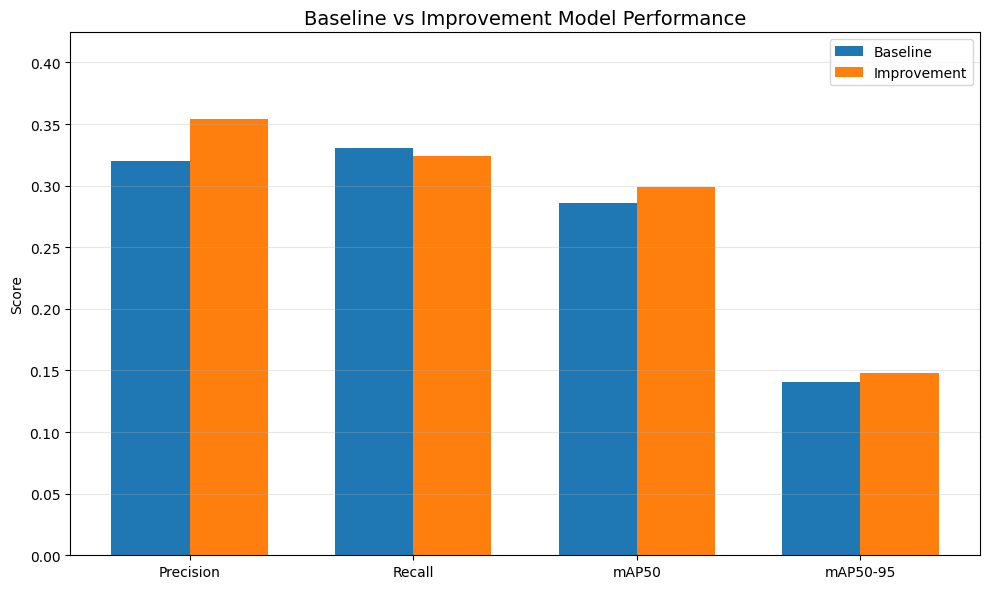

In [23]:
# ============================================================
# Step 15. Evaluate and Compare the Improvement Model
# ============================================================
# 이 단계에서는 Improvement 모델의 best.pt를 불러와
# 통합된 Validation 데이터로 최종 성능을 평가합니다.
#
# 이후 동일한 통합 Validation 데이터로 평가했던
# Baseline 모델과 다음 성능을 비교합니다.
#
# - Precision
# - Recall
# - mAP50
# - mAP50-95
#
# 두 모델이 같은 Validation 이미지와 같은 정답 라벨을
# 사용하므로 성능을 공정하게 비교할 수 있습니다.
#
# 마지막으로 전체 성능 비교표와 클래스별 성능 차이를 저장하고,
# mAP50-95가 높은 모델을 최종 모델로 선택합니다.
# ============================================================


# -----------------------------
# 1. 평가 결과 저장 경로 설정
# -----------------------------
IMPROVED_EVAL_NAME = "yolov8s_improved_evaluation"

IMPROVED_EVAL_DIR = (
    BASELINE_RUNS_DIR / IMPROVED_EVAL_NAME
)


if IMPROVED_EVAL_DIR.exists():
    shutil.rmtree(IMPROVED_EVAL_DIR)


# -----------------------------
# 2. 가장 좋은 Improvement 모델 불러오기
# -----------------------------
improved_best_model = YOLO(
    str(IMPROVED_BEST_MODEL_PATH)
)


# -----------------------------
# 3. 통합 Validation 데이터로 최종 평가
# -----------------------------
improved_val_metrics = improved_best_model.val(

    # Improvement 모델 학습에 사용한 통합 라벨
    data=str(IMPROVED_DATA_YAML_PATH),
    split="val",

    # Improvement 학습과 동일한 이미지 크기
    imgsz=640,
    batch=16,

    device=0,
    workers=2,

    iou=0.7,
    max_det=300,

    plots=True,

    project=str(BASELINE_RUNS_DIR),
    name=IMPROVED_EVAL_NAME,
    exist_ok=True,

    verbose=False
)


# -----------------------------
# 4. Improvement 전체 성능 정리
# -----------------------------
improved_overall_metrics_df = pd.DataFrame([
    {
        "model": "YOLOv8s Improvement",
        "training_labels": "Consensus",
        "evaluation_labels": "Consensus",
        "image_size": 640,

        "precision": float(
            improved_val_metrics.box.mp
        ),

        "recall": float(
            improved_val_metrics.box.mr
        ),

        "mAP50": float(
            improved_val_metrics.box.map50
        ),

        "mAP50_95": float(
            improved_val_metrics.box.map
        )
    }
])


overall_metric_columns = [
    "precision",
    "recall",
    "mAP50",
    "mAP50_95"
]


improved_overall_metrics_df[
    overall_metric_columns
] = improved_overall_metrics_df[
    overall_metric_columns
].round(4)


# -----------------------------
# 5. Improvement 클래스별 성능 가져오기
# -----------------------------
improved_box_metrics = (
    improved_val_metrics.box
)


improved_class_ids = convert_to_numpy(
    improved_box_metrics.ap_class_index
).astype(int)


improved_precision_values = convert_to_numpy(
    improved_box_metrics.p
).astype(float)


improved_recall_values = convert_to_numpy(
    improved_box_metrics.r
).astype(float)


improved_map50_values = convert_to_numpy(
    improved_box_metrics.ap50
).astype(float)


improved_map50_95_values = convert_to_numpy(
    improved_box_metrics.ap
).astype(float)


# -----------------------------
# 6. Improvement 클래스별 성능표 생성
# -----------------------------
improved_class_rows = []


for index, class_id in enumerate(
    improved_class_ids
):

    precision = (
        improved_precision_values[index]
    )

    recall = (
        improved_recall_values[index]
    )

    f1_score = (
        2 * precision * recall
        / (precision + recall + 1e-12)
    )


    improved_class_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id],

        "validation_images": (
            consensus_val_image_counts.get(
                class_id,
                0
            )
        ),

        "validation_boxes": (
            consensus_val_box_counts.get(
                class_id,
                0
            )
        ),

        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,

        "mAP50": (
            improved_map50_values[index]
        ),

        "mAP50_95": (
            improved_map50_95_values[index]
        )
    })


improved_class_metrics_df = pd.DataFrame(
    improved_class_rows
).sort_values(
    by="class_id"
).reset_index(drop=True)


class_metric_columns = [
    "precision",
    "recall",
    "f1_score",
    "mAP50",
    "mAP50_95"
]


improved_class_metrics_df[
    class_metric_columns
] = improved_class_metrics_df[
    class_metric_columns
].round(4)


# -----------------------------
# 7. Baseline과 Improvement 전체 성능 비교
# -----------------------------
model_comparison_df = pd.concat(
    [
        baseline_consensus_overall_df,
        improved_overall_metrics_df
    ],
    ignore_index=True
)


# Baseline과 Improvement의 지표 차이 계산
baseline_metrics = (
    model_comparison_df.iloc[0]
)

improved_metrics = (
    model_comparison_df.iloc[1]
)


performance_change_df = pd.DataFrame([
    {
        "metric": "Precision",
        "baseline": baseline_metrics["precision"],
        "improvement": improved_metrics["precision"],
        "difference": round(
            improved_metrics["precision"]
            - baseline_metrics["precision"],
            4
        )
    },
    {
        "metric": "Recall",
        "baseline": baseline_metrics["recall"],
        "improvement": improved_metrics["recall"],
        "difference": round(
            improved_metrics["recall"]
            - baseline_metrics["recall"],
            4
        )
    },
    {
        "metric": "mAP50",
        "baseline": baseline_metrics["mAP50"],
        "improvement": improved_metrics["mAP50"],
        "difference": round(
            improved_metrics["mAP50"]
            - baseline_metrics["mAP50"],
            4
        )
    },
    {
        "metric": "mAP50-95",
        "baseline": baseline_metrics["mAP50_95"],
        "improvement": improved_metrics["mAP50_95"],
        "difference": round(
            improved_metrics["mAP50_95"]
            - baseline_metrics["mAP50_95"],
            4
        )
    }
])


# -----------------------------
# 8. 클래스별 mAP50-95 비교
# -----------------------------
class_comparison_df = (
    baseline_consensus_class_df[
        [
            "class_id",
            "class_name",
            "mAP50_95"
        ]
    ]
    .rename(
        columns={
            "mAP50_95": "baseline_mAP50_95"
        }
    )
    .merge(
        improved_class_metrics_df[
            [
                "class_id",
                "class_name",
                "mAP50_95"
            ]
        ].rename(
            columns={
                "mAP50_95": "improved_mAP50_95"
            }
        ),
        on=["class_id", "class_name"],
        how="inner"
    )
)


class_comparison_df["difference"] = (
    class_comparison_df["improved_mAP50_95"]
    - class_comparison_df["baseline_mAP50_95"]
).round(4)


class_comparison_df = (
    class_comparison_df
    .sort_values(
        by="difference",
        ascending=False
    )
    .reset_index(drop=True)
)


# -----------------------------
# 9. 최종 모델 선택
# -----------------------------
baseline_map = float(
    baseline_consensus_overall_df.loc[
        0,
        "mAP50_95"
    ]
)

improved_map = float(
    improved_overall_metrics_df.loc[
        0,
        "mAP50_95"
    ]
)


if improved_map > baseline_map:

    FINAL_MODEL_NAME = (
        "YOLOv8s Improvement"
    )

    FINAL_MODEL_PATH = (
        IMPROVED_BEST_MODEL_PATH
    )

else:

    FINAL_MODEL_NAME = (
        "YOLOv8s Baseline"
    )

    FINAL_MODEL_PATH = (
        BASELINE_BEST_MODEL_PATH
    )


# -----------------------------
# 10. 결과 CSV 저장
# -----------------------------
IMPROVED_OVERALL_CSV_PATH = (
    OUTPUT_DIR
    / "improved_overall_metrics.csv"
)

IMPROVED_CLASS_CSV_PATH = (
    OUTPUT_DIR
    / "improved_class_metrics.csv"
)

MODEL_COMPARISON_CSV_PATH = (
    OUTPUT_DIR
    / "baseline_improvement_comparison.csv"
)

CLASS_COMPARISON_CSV_PATH = (
    OUTPUT_DIR
    / "class_performance_comparison.csv"
)


improved_overall_metrics_df.to_csv(
    IMPROVED_OVERALL_CSV_PATH,
    index=False
)

improved_class_metrics_df.to_csv(
    IMPROVED_CLASS_CSV_PATH,
    index=False
)

model_comparison_df.to_csv(
    MODEL_COMPARISON_CSV_PATH,
    index=False
)

class_comparison_df.to_csv(
    CLASS_COMPARISON_CSV_PATH,
    index=False
)


# -----------------------------
# 11. 결과 출력
# -----------------------------
print("=" * 70)
print("Baseline and Improvement Model Comparison")
print("=" * 70)

print("전체 모델 성능")
display(model_comparison_df)

print()
print("지표별 성능 변화")
display(performance_change_df)

print()
print("클래스별 mAP50-95 변화")
display(class_comparison_df)

print("=" * 70)

print(f"Selected final model : {FINAL_MODEL_NAME}")
print(f"Final model path     : {FINAL_MODEL_PATH}")

print(
    f"Baseline mAP50-95    : "
    f"{baseline_map:.4f}"
)

print(
    f"Improvement mAP50-95 : "
    f"{improved_map:.4f}"
)

print(
    f"mAP50-95 difference  : "
    f"{improved_map - baseline_map:+.4f}"
)

print("=" * 70)


# -----------------------------
# 12. 전체 성능 비교 그래프
# -----------------------------
plot_metrics = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]


baseline_plot_values = [
    baseline_metrics["precision"],
    baseline_metrics["recall"],
    baseline_metrics["mAP50"],
    baseline_metrics["mAP50_95"]
]


improved_plot_values = [
    improved_metrics["precision"],
    improved_metrics["recall"],
    improved_metrics["mAP50"],
    improved_metrics["mAP50_95"]
]


x_positions = np.arange(
    len(plot_metrics)
)

bar_width = 0.35


plt.figure(figsize=(10, 6))


plt.bar(
    x_positions - bar_width / 2,
    baseline_plot_values,
    width=bar_width,
    label="Baseline"
)


plt.bar(
    x_positions + bar_width / 2,
    improved_plot_values,
    width=bar_width,
    label="Improvement"
)


plt.xticks(
    x_positions,
    plot_metrics
)

plt.ylabel("Score")

plt.title(
    "Baseline vs Improvement Model Performance",
    fontsize=14
)

plt.ylim(
    0,
    max(
        baseline_plot_values
        + improved_plot_values
    ) * 1.20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

GPU 메모리 정리 완료

Final Model Prediction Setup
Final model          : YOLOv8s Improvement
Image size           : 640
Confidence threshold : 0.25
Matching IoU         : 0.5
Validation images    : 2,980


Analyzing final model predictions:   0%|          | 0/2980 [00:00<?, ?it/s]


예측 완료: 2,980개 이미지


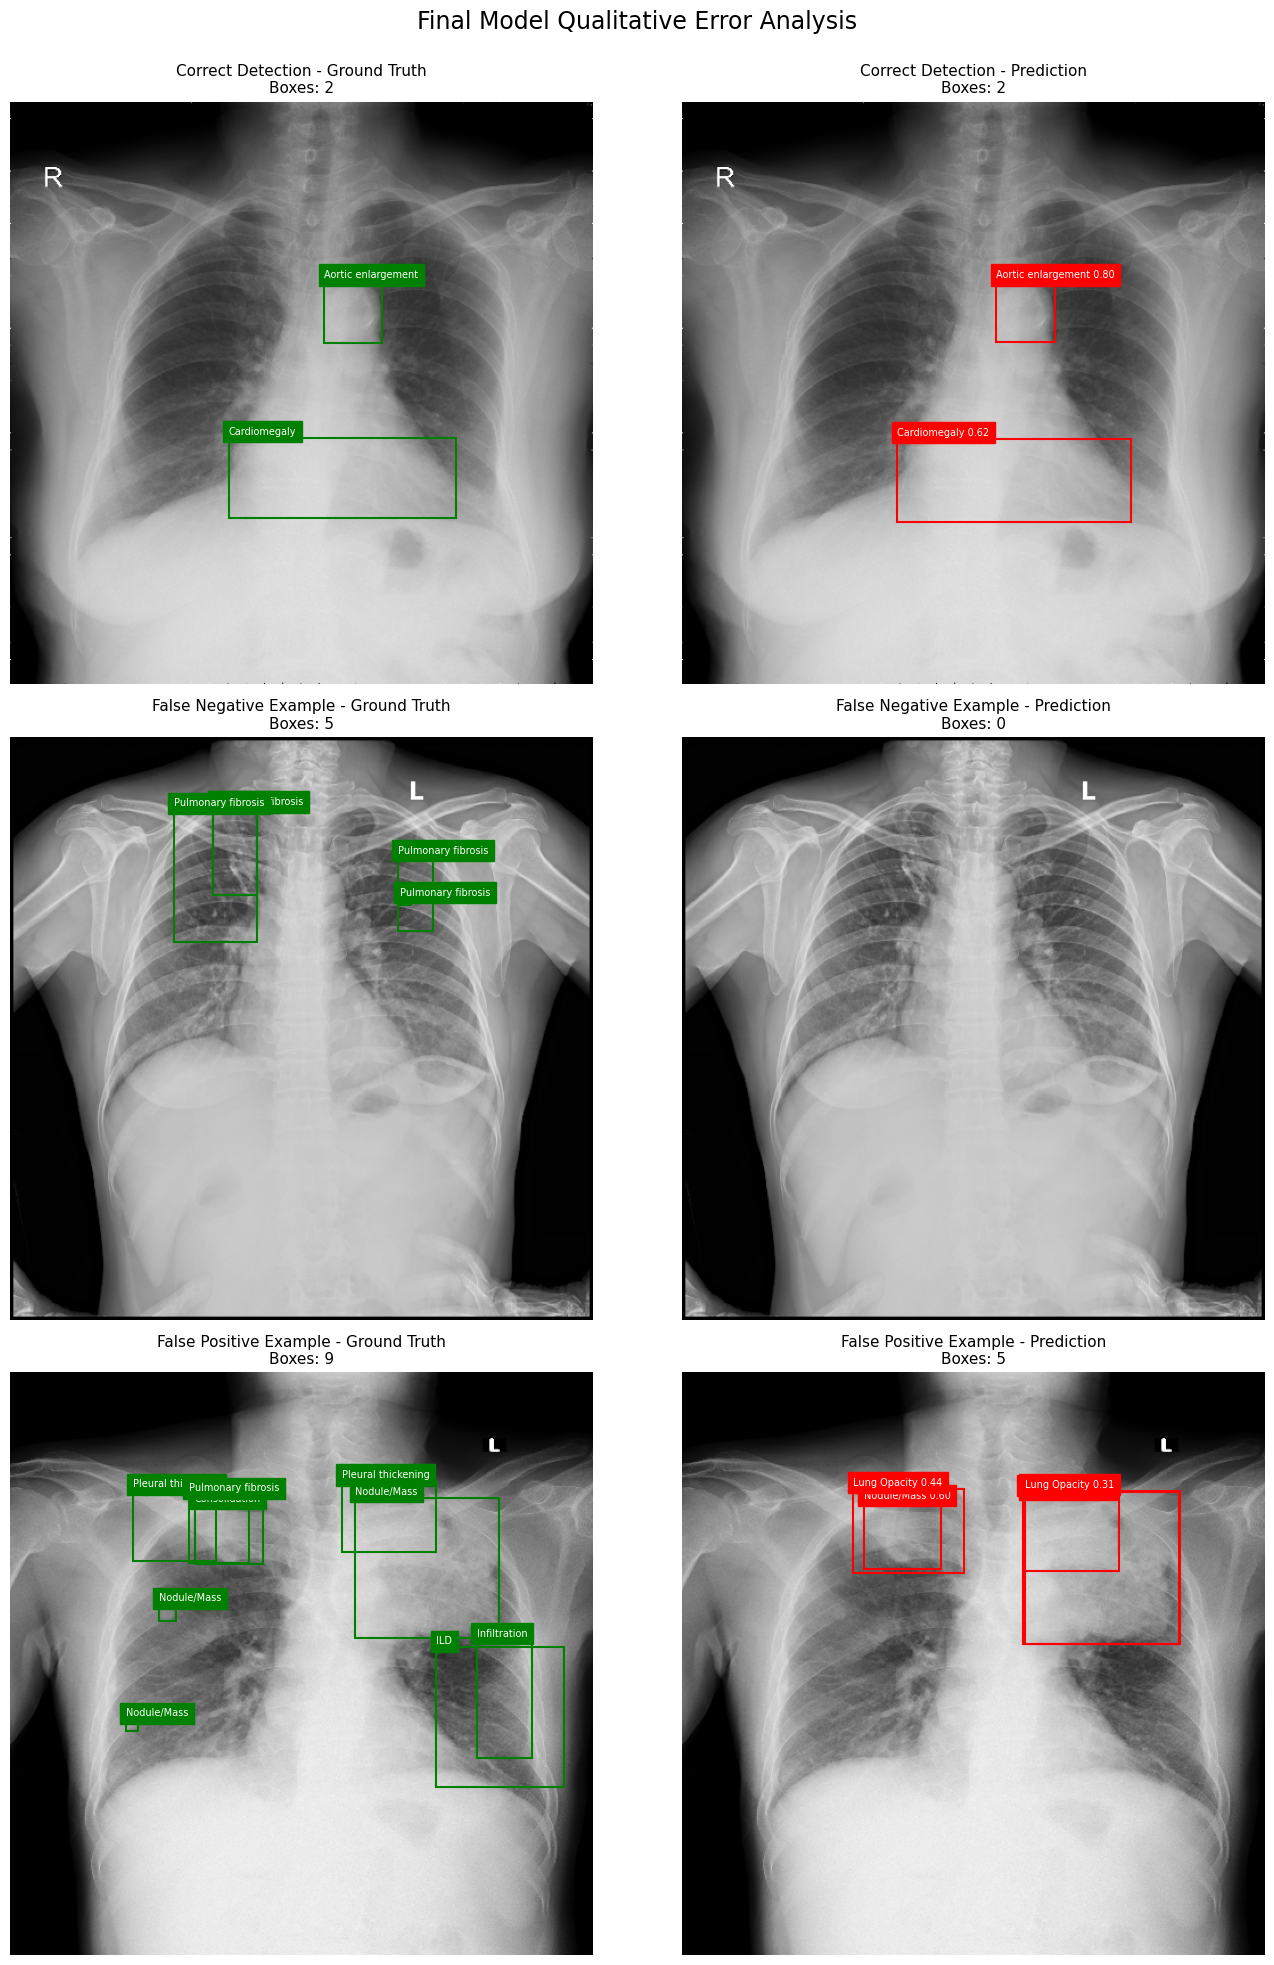

Final Model Qualitative Analysis Result
Analyzed images       : 2,980
True Positive boxes   : 1,272
False Positive boxes  : 367
False Negative boxes  : 3,575
Analysis CSV          : /kaggle/working/vinbigdata_yolo/outputs/final_prediction_error_analysis.csv
Visualization saved   : /kaggle/working/vinbigdata_yolo/outputs/final_model_error_analysis.png


,example_type,image_id,ground_truth_count,prediction_count,true_positive,false_positive,false_negative
4,False Negative,001d127bad87592efe45a5c7678f8b8d,5,0,0,0,5
17,Correct Detection,015e332b702e4829710941ab7265bd1d,2,2,2,0,0
2244,False Positive,be85b7d55e0ef589729ef4dd6ffc38fb,9,5,0,5,9


Step 16 완료: 최종 모델 예측 및 오류 분석이 저장되었습니다.


In [25]:
# ============================================================
# Step 16. Visualize Predictions and Analyze Detection Errors
# ============================================================
# 이 단계에서는 최종 모델을 전체 Validation 이미지에 적용하여
# 실제 Bounding Box와 예측 Bounding Box를 비교합니다.
#
# 확인할 사례:
# - Correct Detection: 실제 병변을 올바르게 탐지한 사례
# - False Negative: 실제 병변을 모델이 놓친 사례
# - False Positive: 실제 병변이 아닌 위치를 잘못 탐지한 사례
#
# GPU 메모리 부족을 방지하기 위해 다음 방법을 사용합니다.
# - 이전 단계에서 사용한 모델 객체와 GPU 메모리 정리
# - 이미지 폴더를 source로 전달
# - batch=4로 작은 단위 예측
# - half=True로 FP16 연산 사용
# - stream=True로 결과를 한 번에 저장하지 않고 순서대로 처리
#
# Ground Truth와 Prediction의 클래스가 같고,
# 두 Bounding Box의 IoU가 0.5 이상이면 올바른 탐지로 계산합니다.
#
# 참고:
# conf=0.25는 예측 결과를 시각화하고 오류 사례를 분석하기 위한
# 기준이며, 앞에서 계산한 공식 mAP 평가 결과에는 영향을 주지 않습니다.
# ============================================================


# -----------------------------
# 1. GPU 메모리 정리
# -----------------------------
import gc


# 이전 학습 및 평가에서 사용한 모델 객체를 정리한다.
model_variables_to_clear = [
    "baseline_model",
    "baseline_best_model",
    "baseline_consensus_model",
    "improved_model",
    "improved_best_model",
    "final_model"
]


for variable_name in model_variables_to_clear:

    if variable_name in globals():
        globals()[variable_name] = None


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


print("GPU 메모리 정리 완료")


# -----------------------------
# 2. 최종 모델 불러오기
# -----------------------------
final_model = YOLO(
    str(FINAL_MODEL_PATH)
)


# 최종 모델에 맞는 입력 이미지 크기 설정
if FINAL_MODEL_NAME == "YOLOv8s Improvement":

    FINAL_IMAGE_SIZE = 640

else:

    FINAL_IMAGE_SIZE = 512


# 정성적 분석용 설정
PREDICTION_CONFIDENCE = 0.25
MATCH_IOU_THRESHOLD = 0.50


# -----------------------------
# 3. Validation 이미지와 라벨 목록 준비
# -----------------------------
final_val_image_paths = sorted(
    IMPROVED_VAL_IMAGE_DIR.glob("*")
)


final_val_label_paths = {
    path.stem: path
    for path in IMPROVED_VAL_LABEL_DIR.glob("*.txt")
}


print()
print("=" * 60)
print("Final Model Prediction Setup")
print("=" * 60)

print(
    f"Final model          : "
    f"{FINAL_MODEL_NAME}"
)

print(
    f"Image size           : "
    f"{FINAL_IMAGE_SIZE}"
)

print(
    f"Confidence threshold : "
    f"{PREDICTION_CONFIDENCE}"
)

print(
    f"Matching IoU         : "
    f"{MATCH_IOU_THRESHOLD}"
)

print(
    f"Validation images    : "
    f"{len(final_val_image_paths):,}"
)

print("=" * 60)


# -----------------------------
# 4. YOLO 라벨을 픽셀 좌표로 변환하는 함수
# -----------------------------
def read_yolo_ground_truth(
    label_path,
    image_width,
    image_height
):
    """
    YOLO txt 라벨을 읽고 픽셀 단위의
    [x_min, y_min, x_max, y_max] 좌표로 변환합니다.
    """

    label_text = label_path.read_text(
        encoding="utf-8"
    ).strip()


    ground_truth_boxes = []
    ground_truth_classes = []


    # 정상 이미지는 빈 라벨 파일을 사용한다.
    if not label_text:

        return (
            np.empty((0, 4), dtype=float),
            np.empty((0,), dtype=int)
        )


    for line in label_text.splitlines():

        values = line.split()


        class_id = int(values[0])

        x_center = float(values[1])
        y_center = float(values[2])
        box_width = float(values[3])
        box_height = float(values[4])


        # 정규화 좌표를 픽셀 좌표로 변환
        x_center_pixel = (
            x_center * image_width
        )

        y_center_pixel = (
            y_center * image_height
        )

        box_width_pixel = (
            box_width * image_width
        )

        box_height_pixel = (
            box_height * image_height
        )


        x_min = (
            x_center_pixel
            - box_width_pixel / 2
        )

        y_min = (
            y_center_pixel
            - box_height_pixel / 2
        )

        x_max = (
            x_center_pixel
            + box_width_pixel / 2
        )

        y_max = (
            y_center_pixel
            + box_height_pixel / 2
        )


        ground_truth_boxes.append([
            x_min,
            y_min,
            x_max,
            y_max
        ])


        ground_truth_classes.append(
            class_id
        )


    return (
        np.asarray(
            ground_truth_boxes,
            dtype=float
        ),
        np.asarray(
            ground_truth_classes,
            dtype=int
        )
    )


# -----------------------------
# 5. 예측과 실제 박스를 비교하는 함수
# -----------------------------
def match_predictions_to_ground_truth(
    ground_truth_boxes,
    ground_truth_classes,
    prediction_boxes,
    prediction_classes,
    iou_threshold=0.5
):
    """
    예측 박스와 실제 박스를 클래스와 IoU를 기준으로 비교합니다.

    TP:
        실제 병변을 올바르게 찾은 예측

    FP:
        실제 병변과 연결되지 않은 잘못된 예측

    FN:
        모델이 찾지 못한 실제 병변
    """

    matched_ground_truth = set()

    true_positive_count = 0
    false_positive_count = 0


    # 예측 박스를 하나씩 확인한다.
    for prediction_index, prediction_box in enumerate(
        prediction_boxes
    ):

        prediction_class = int(
            prediction_classes[prediction_index]
        )


        best_iou = 0.0
        best_ground_truth_index = None


        # 현재 예측 박스와 모든 실제 박스를 비교한다.
        for ground_truth_index, ground_truth_box in enumerate(
            ground_truth_boxes
        ):

            # 이미 다른 예측과 연결된 실제 박스는 제외한다.
            if ground_truth_index in matched_ground_truth:
                continue


            # 클래스가 다르면 같은 병변으로 인정하지 않는다.
            if (
                int(
                    ground_truth_classes[
                        ground_truth_index
                    ]
                )
                != prediction_class
            ):
                continue


            current_iou = calculate_box_iou(
                prediction_box,
                ground_truth_box
            )


            if current_iou > best_iou:

                best_iou = current_iou

                best_ground_truth_index = (
                    ground_truth_index
                )


        # 같은 클래스이며 IoU가 기준 이상인 경우
        if (
            best_ground_truth_index is not None
            and best_iou >= iou_threshold
        ):

            true_positive_count += 1

            matched_ground_truth.add(
                best_ground_truth_index
            )


        # 연결되는 실제 박스가 없는 경우
        else:

            false_positive_count += 1


    false_negative_count = (
        len(ground_truth_boxes)
        - len(matched_ground_truth)
    )


    return {
        "true_positive": true_positive_count,
        "false_positive": false_positive_count,
        "false_negative": false_negative_count
    }


# -----------------------------
# 6. 전체 Validation 이미지 예측
# -----------------------------
prediction_summary_rows = []

prediction_cache = {}


# 이미지 경로 전체 리스트가 아니라
# Validation 이미지 폴더를 source로 전달한다.
prediction_results = final_model.predict(

    source=str(
        IMPROVED_VAL_IMAGE_DIR
    ),

    imgsz=FINAL_IMAGE_SIZE,

    conf=PREDICTION_CONFIDENCE,
    iou=0.50,

    max_det=100,

    # 메모리 부족을 방지하기 위해 작은 Batch 사용
    batch=4,

    device=0,

    # T4 GPU에서 FP16 연산 사용
    half=True,

    # 결과를 한 번에 저장하지 않고 순서대로 반환
    stream=True,

    verbose=False
)


for result in tqdm(
    prediction_results,
    total=len(final_val_image_paths),
    desc="Analyzing final model predictions"
):

    image_path = Path(
        result.path
    )

    image_id = image_path.stem


    image_height, image_width = (
        result.orig_shape
    )


    # 실제 라벨 경로 확인
    label_path = final_val_label_paths.get(
        image_id
    )


    if label_path is None:

        print(
            f"라벨 파일을 찾지 못했습니다: "
            f"{image_id}"
        )

        continue


    # 실제 Bounding Box 읽기
    ground_truth_boxes, ground_truth_classes = (
        read_yolo_ground_truth(
            label_path=label_path,
            image_width=image_width,
            image_height=image_height
        )
    )


    # 모델 예측 Bounding Box 읽기
    if (
        result.boxes is not None
        and len(result.boxes) > 0
    ):

        prediction_boxes = (
            result.boxes.xyxy
            .detach()
            .cpu()
            .numpy()
            .astype(float)
        )


        prediction_classes = (
            result.boxes.cls
            .detach()
            .cpu()
            .numpy()
            .astype(int)
        )


        prediction_scores = (
            result.boxes.conf
            .detach()
            .cpu()
            .numpy()
            .astype(float)
        )


    else:

        prediction_boxes = np.empty(
            (0, 4),
            dtype=float
        )


        prediction_classes = np.empty(
            (0,),
            dtype=int
        )


        prediction_scores = np.empty(
            (0,),
            dtype=float
        )


    # 예측과 실제 라벨 비교
    match_result = (
        match_predictions_to_ground_truth(
            ground_truth_boxes=ground_truth_boxes,
            ground_truth_classes=ground_truth_classes,
            prediction_boxes=prediction_boxes,
            prediction_classes=prediction_classes,
            iou_threshold=MATCH_IOU_THRESHOLD
        )
    )


    prediction_summary_rows.append({
        "image_id": image_id,

        "ground_truth_count": len(
            ground_truth_boxes
        ),

        "prediction_count": len(
            prediction_boxes
        ),

        "true_positive": (
            match_result[
                "true_positive"
            ]
        ),

        "false_positive": (
            match_result[
                "false_positive"
            ]
        ),

        "false_negative": (
            match_result[
                "false_negative"
            ]
        )
    })


    # 대표 사례 시각화에 사용할 좌표 저장
    prediction_cache[image_id] = {

        "ground_truth_boxes":
        ground_truth_boxes,

        "ground_truth_classes":
        ground_truth_classes,

        "prediction_boxes":
        prediction_boxes,

        "prediction_classes":
        prediction_classes,

        "prediction_scores":
        prediction_scores
    }


    # 현재 result 객체가 가진 GPU Tensor 정리
    del result


print()
print(
    f"예측 완료: "
    f"{len(prediction_summary_rows):,}개 이미지"
)


# -----------------------------
# 7. 이미지별 오류 분석표 생성
# -----------------------------
prediction_analysis_df = pd.DataFrame(
    prediction_summary_rows
)


PREDICTION_ANALYSIS_CSV_PATH = (
    OUTPUT_DIR
    / "final_prediction_error_analysis.csv"
)


prediction_analysis_df.to_csv(
    PREDICTION_ANALYSIS_CSV_PATH,
    index=False
)


# -----------------------------
# 8. 대표 사례 선택
# -----------------------------
selected_image_ids = []


# Correct Detection:
# TP가 존재하고 FP와 FN이 모두 없는 이미지
correct_candidates = prediction_analysis_df[
    (prediction_analysis_df["true_positive"] > 0)
    & (prediction_analysis_df["false_positive"] == 0)
    & (prediction_analysis_df["false_negative"] == 0)
    & (prediction_analysis_df["ground_truth_count"] <= 4)
]


if len(correct_candidates) > 0:

    correct_image_id = (
        correct_candidates
        .sort_values(
            by="true_positive",
            ascending=False
        )
        .iloc[0]["image_id"]
    )


else:

    # 완벽한 탐지 사례가 없다면
    # TP가 있으면서 오류가 가장 적은 이미지를 선택한다.
    fallback_correct_df = (
        prediction_analysis_df[
            prediction_analysis_df[
                "true_positive"
            ] > 0
        ]
        .copy()
    )


    fallback_correct_df["total_error"] = (
        fallback_correct_df["false_positive"]
        + fallback_correct_df["false_negative"]
    )


    fallback_correct_df = (
        fallback_correct_df
        .sort_values(
            by=[
                "total_error",
                "true_positive"
            ],
            ascending=[
                True,
                False
            ]
        )
    )


    if len(fallback_correct_df) > 0:

        correct_image_id = (
            fallback_correct_df
            .iloc[0]["image_id"]
        )


    else:

        correct_image_id = (
            prediction_analysis_df
            .iloc[0]["image_id"]
        )


selected_image_ids.append(
    correct_image_id
)


# False Negative:
# 실제 병변을 한 개 이상 놓친 이미지
false_negative_candidates = prediction_analysis_df[
    (prediction_analysis_df["false_negative"] > 0)
    & (
        ~prediction_analysis_df["image_id"]
        .isin(selected_image_ids)
    )
    & (
        prediction_analysis_df[
            "ground_truth_count"
        ] <= 5
    )
]


if len(false_negative_candidates) > 0:

    false_negative_image_id = (
        false_negative_candidates
        .sort_values(
            by=[
                "false_negative",
                "ground_truth_count"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]["image_id"]
    )


else:

    fallback_fn_df = prediction_analysis_df[
        ~prediction_analysis_df["image_id"]
        .isin(selected_image_ids)
    ]


    false_negative_image_id = (
        fallback_fn_df
        .iloc[0]["image_id"]
    )


selected_image_ids.append(
    false_negative_image_id
)


# False Positive:
# 실제 병변과 맞지 않는 예측 박스가 있는 이미지
false_positive_candidates = prediction_analysis_df[
    (prediction_analysis_df["false_positive"] > 0)
    & (
        ~prediction_analysis_df["image_id"]
        .isin(selected_image_ids)
    )
    & (
        prediction_analysis_df[
            "prediction_count"
        ] <= 5
    )
]


if len(false_positive_candidates) > 0:

    false_positive_image_id = (
        false_positive_candidates
        .sort_values(
            by="false_positive",
            ascending=False
        )
        .iloc[0]["image_id"]
    )


else:

    fallback_fp_df = prediction_analysis_df[
        ~prediction_analysis_df["image_id"]
        .isin(selected_image_ids)
    ]


    false_positive_image_id = (
        fallback_fp_df
        .iloc[0]["image_id"]
    )


selected_examples = [
    (
        "Correct Detection",
        correct_image_id
    ),
    (
        "False Negative Example",
        false_negative_image_id
    ),
    (
        "False Positive Example",
        false_positive_image_id
    )
]


# -----------------------------
# 9. Bounding Box 표시 함수
# -----------------------------
def draw_detection_boxes(
    ax,
    image,
    boxes,
    classes,
    title,
    scores=None,
    box_color="red"
):
    """
    실제 또는 예측 Bounding Box를
    X-ray 이미지 위에 표시합니다.
    """

    ax.imshow(
        image
    )


    for box_index, box in enumerate(
        boxes
    ):

        x_min, y_min, x_max, y_max = box


        class_id = int(
            classes[box_index]
        )


        rectangle = patches.Rectangle(

            (x_min, y_min),

            x_max - x_min,
            y_max - y_min,

            linewidth=1.5,

            edgecolor=box_color,
            facecolor="none"
        )


        ax.add_patch(
            rectangle
        )


        label_text = CLASS_NAMES[
            class_id
        ]


        # 예측 박스에는 신뢰도를 함께 표시한다.
        if scores is not None:

            label_text += (
                f" {scores[box_index]:.2f}"
            )


        ax.text(

            x_min,
            max(y_min - 3, 0),

            label_text,

            fontsize=7,

            color="white",
            backgroundcolor=box_color
        )


    ax.set_title(
        f"{title}\n"
        f"Boxes: {len(boxes)}",
        fontsize=11
    )


    ax.axis(
        "off"
    )


# -----------------------------
# 10. 실제 라벨과 예측 결과 시각화
# -----------------------------
fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 20)
)


for row_index, (
    example_name,
    image_id
) in enumerate(
    selected_examples
):

    image_path = image_path_dict[
        image_id
    ]


    image = cv2.imread(
        str(image_path)
    )


    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


    cached_result = prediction_cache[
        image_id
    ]


    # 왼쪽: 실제 Bounding Box
    draw_detection_boxes(

        ax=axes[row_index, 0],

        image=image,

        boxes=cached_result[
            "ground_truth_boxes"
        ],

        classes=cached_result[
            "ground_truth_classes"
        ],

        title=(
            f"{example_name} - Ground Truth"
        ),

        scores=None,

        box_color="green"
    )


    # 오른쪽: 모델 예측 Bounding Box
    draw_detection_boxes(

        ax=axes[row_index, 1],

        image=image,

        boxes=cached_result[
            "prediction_boxes"
        ],

        classes=cached_result[
            "prediction_classes"
        ],

        title=(
            f"{example_name} - Prediction"
        ),

        scores=cached_result[
            "prediction_scores"
        ],

        box_color="red"
    )


plt.suptitle(
    "Final Model Qualitative Error Analysis",
    fontsize=17
)


plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


FINAL_ERROR_ANALYSIS_IMAGE_PATH = (
    OUTPUT_DIR
    / "final_model_error_analysis.png"
)


plt.savefig(
    FINAL_ERROR_ANALYSIS_IMAGE_PATH,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# -----------------------------
# 11. 전체 분석 결과 계산
# -----------------------------
total_true_positives = int(
    prediction_analysis_df[
        "true_positive"
    ].sum()
)


total_false_positives = int(
    prediction_analysis_df[
        "false_positive"
    ].sum()
)


total_false_negatives = int(
    prediction_analysis_df[
        "false_negative"
    ].sum()
)


print("=" * 70)
print("Final Model Qualitative Analysis Result")
print("=" * 70)


print(
    f"Analyzed images       : "
    f"{len(prediction_analysis_df):,}"
)


print(
    f"True Positive boxes   : "
    f"{total_true_positives:,}"
)


print(
    f"False Positive boxes  : "
    f"{total_false_positives:,}"
)


print(
    f"False Negative boxes  : "
    f"{total_false_negatives:,}"
)


print(
    f"Analysis CSV          : "
    f"{PREDICTION_ANALYSIS_CSV_PATH}"
)


print(
    f"Visualization saved   : "
    f"{FINAL_ERROR_ANALYSIS_IMAGE_PATH}"
)


print("=" * 70)


# -----------------------------
# 12. 선택된 대표 이미지 정보 출력
# -----------------------------
selected_example_df = prediction_analysis_df[
    prediction_analysis_df["image_id"].isin(
        [
            correct_image_id,
            false_negative_image_id,
            false_positive_image_id
        ]
    )
].copy()


selected_example_df["example_type"] = (
    selected_example_df["image_id"].map({

        correct_image_id:
        "Correct Detection",

        false_negative_image_id:
        "False Negative",

        false_positive_image_id:
        "False Positive"
    })
)


selected_example_df = selected_example_df[
    [
        "example_type",
        "image_id",
        "ground_truth_count",
        "prediction_count",
        "true_positive",
        "false_positive",
        "false_negative"
    ]
]


display(
    selected_example_df
)


# -----------------------------
# 13. 작업 종료 후 GPU 메모리 정리
# -----------------------------
gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "Step 16 완료: 최종 모델 예측 및 오류 분석이 저장되었습니다."
)

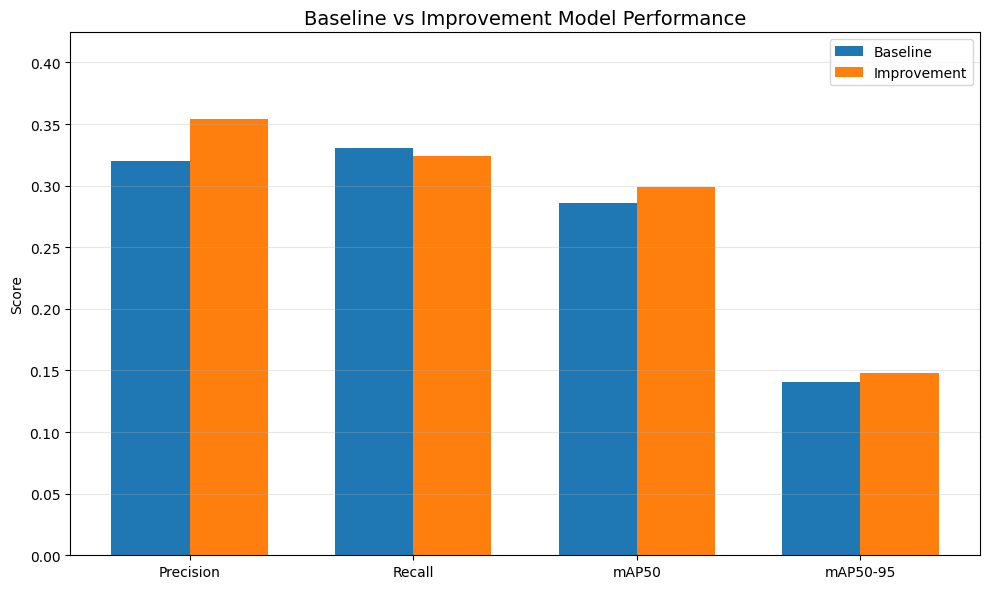

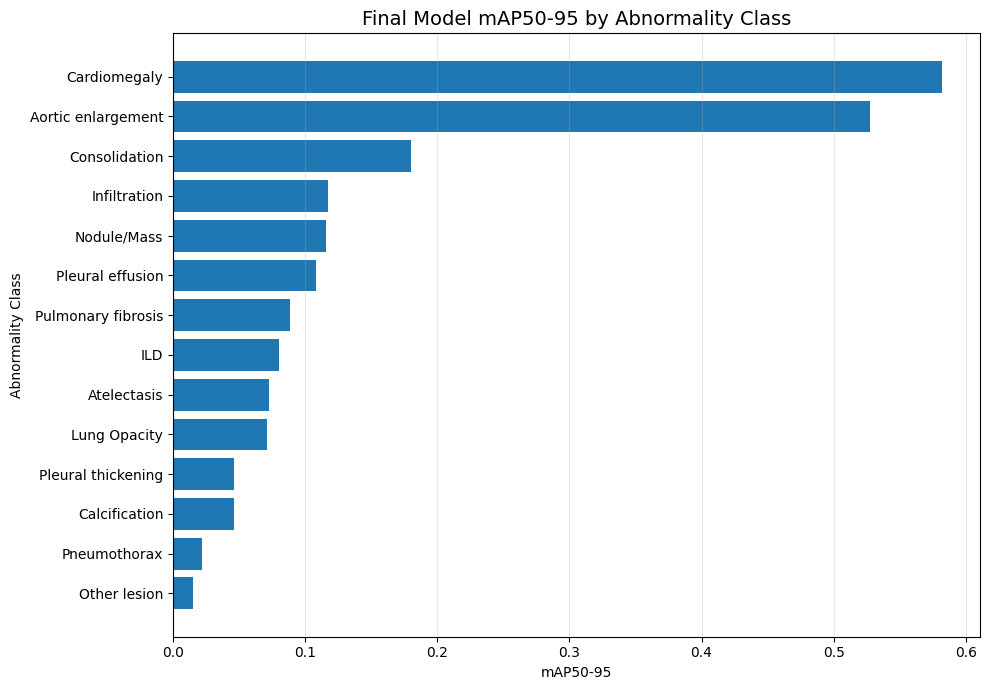

Final Portfolio Export Result


,project_name,task,model,total_images,train_images,validation_images,normal_images,abnormal_images,original_bounding_boxes,consensus_bounding_boxes,...,baseline_mAP50,baseline_mAP50_95,improved_image_size,improved_precision,improved_recall,improved_mAP50,improved_mAP50_95,mAP50_95_absolute_change,mAP50_95_relative_change_percent,selected_final_model
0,VinBigData Chest X-ray Abnormality Detection,14-class Object Detection,YOLOv8s,15000,12020,2980,10606,4394,36096,23940,...,0.2862,0.1408,640,0.3537,0.3241,0.2992,0.1481,0.0073,5.18,YOLOv8s Improvement



Exported Files


,file_name,file_size_mb
0,baseline_improvement_comparison.csv,0.000
1,class_performance_comparison.csv,0.001
2,consensus_bounding_boxes.csv,2.212
3,final_class_performance.png,0.099
4,final_model_error_analysis.png,2.237
5,final_prediction_error_analysis.csv,0.122
6,improved_class_metrics.csv,0.001
7,improved_overall_metrics.csv,0.000
8,model_performance_comparison.png,0.061
9,project_summary.csv,0.001


Final model      : /kaggle/working/vinbigdata_yolo/final_portfolio_outputs/vinbigdata_yolov8s_final_best.pt
Summary CSV      : /kaggle/working/vinbigdata_yolo/final_portfolio_outputs/project_summary.csv
Summary Markdown : /kaggle/working/vinbigdata_yolo/final_portfolio_outputs/project_summary.md
Output folder    : /kaggle/working/vinbigdata_yolo/final_portfolio_outputs
ZIP file         : /kaggle/working/vinbigdata_yolo/vinbigdata_yolo_portfolio_outputs.zip
Step 17 완료: 최종 모델과 포트폴리오 결과가 저장되었습니다.


In [26]:
# ============================================================
# Step 17. Summarize and Export the Final Project Results
# ============================================================
# 이 단계에서는 프로젝트의 주요 결과를 하나의 표로 정리하고,
# 회사 포트폴리오와 GitHub에 사용할 핵심 파일을 한 폴더에 저장합니다.
#
# 저장할 내용:
# - 최종 YOLOv8s 모델
# - Baseline과 Improvement 모델 비교 결과
# - 클래스별 탐지 성능
# - 최종 오류 분석 결과
# - 모델 성능 비교 그래프
# - 클래스별 mAP50-95 그래프
# - 프로젝트 최종 요약 CSV와 Markdown
#
# 마지막에는 모든 결과를 ZIP 파일로 압축하여
# Kaggle에서 한 번에 내려받을 수 있도록 준비합니다.
# ============================================================


# -----------------------------
# 1. 최종 결과 저장 폴더 생성
# -----------------------------
FINAL_EXPORT_DIR = (
    PROJECT_DIR / "final_portfolio_outputs"
)


# 이전 결과가 있으면 삭제하고 다시 생성
if FINAL_EXPORT_DIR.exists():
    shutil.rmtree(FINAL_EXPORT_DIR)


FINAL_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -----------------------------
# 2. 최종 핵심 성능 가져오기
# -----------------------------
baseline_precision = float(
    baseline_consensus_overall_df.loc[
        0,
        "precision"
    ]
)

baseline_recall = float(
    baseline_consensus_overall_df.loc[
        0,
        "recall"
    ]
)

baseline_map50 = float(
    baseline_consensus_overall_df.loc[
        0,
        "mAP50"
    ]
)

baseline_map50_95 = float(
    baseline_consensus_overall_df.loc[
        0,
        "mAP50_95"
    ]
)


improved_precision = float(
    improved_overall_metrics_df.loc[
        0,
        "precision"
    ]
)

improved_recall = float(
    improved_overall_metrics_df.loc[
        0,
        "recall"
    ]
)

improved_map50 = float(
    improved_overall_metrics_df.loc[
        0,
        "mAP50"
    ]
)

improved_map50_95 = float(
    improved_overall_metrics_df.loc[
        0,
        "mAP50_95"
    ]
)


# mAP50-95의 절대 변화
map_absolute_change = (
    improved_map50_95
    - baseline_map50_95
)


# Baseline 대비 상대적인 향상률
map_relative_change_percent = (
    map_absolute_change
    / baseline_map50_95
    * 100
)


# -----------------------------
# 3. 프로젝트 최종 요약표 만들기
# -----------------------------
project_summary_df = pd.DataFrame([
    {
        "project_name":
        "VinBigData Chest X-ray Abnormality Detection",

        "task":
        "14-class Object Detection",

        "model":
        "YOLOv8s",

        "total_images":
        total_images,

        "train_images":
        len(train_image_ids),

        "validation_images":
        len(val_image_ids),

        "normal_images":
        normal_images,

        "abnormal_images":
        abnormal_images,

        "original_bounding_boxes":
        original_box_count,

        "consensus_bounding_boxes":
        merged_box_count,

        "box_reduction_percent":
        round(reduction_ratio, 2),

        "baseline_image_size":
        512,

        "baseline_precision":
        baseline_precision,

        "baseline_recall":
        baseline_recall,

        "baseline_mAP50":
        baseline_map50,

        "baseline_mAP50_95":
        baseline_map50_95,

        "improved_image_size":
        640,

        "improved_precision":
        improved_precision,

        "improved_recall":
        improved_recall,

        "improved_mAP50":
        improved_map50,

        "improved_mAP50_95":
        improved_map50_95,

        "mAP50_95_absolute_change":
        round(map_absolute_change, 4),

        "mAP50_95_relative_change_percent":
        round(map_relative_change_percent, 2),

        "selected_final_model":
        FINAL_MODEL_NAME
    }
])


PROJECT_SUMMARY_CSV_PATH = (
    FINAL_EXPORT_DIR
    / "project_summary.csv"
)


project_summary_df.to_csv(
    PROJECT_SUMMARY_CSV_PATH,
    index=False
)


# -----------------------------
# 4. 최종 모델 파일 복사
# -----------------------------
FINAL_EXPORTED_MODEL_PATH = (
    FINAL_EXPORT_DIR
    / "vinbigdata_yolov8s_final_best.pt"
)


shutil.copy2(
    FINAL_MODEL_PATH,
    FINAL_EXPORTED_MODEL_PATH
)


# -----------------------------
# 5. 모델 비교 결과 그래프 저장
# -----------------------------
metric_names = [
    "Precision",
    "Recall",
    "mAP50",
    "mAP50-95"
]


baseline_values = [
    baseline_precision,
    baseline_recall,
    baseline_map50,
    baseline_map50_95
]


improved_values = [
    improved_precision,
    improved_recall,
    improved_map50,
    improved_map50_95
]


x_positions = np.arange(
    len(metric_names)
)

bar_width = 0.35


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    x_positions - bar_width / 2,
    baseline_values,
    width=bar_width,
    label="Baseline"
)


plt.bar(
    x_positions + bar_width / 2,
    improved_values,
    width=bar_width,
    label="Improvement"
)


plt.xticks(
    x_positions,
    metric_names
)

plt.ylabel(
    "Score"
)

plt.title(
    "Baseline vs Improvement Model Performance",
    fontsize=14
)

plt.ylim(
    0,
    max(
        baseline_values
        + improved_values
    ) * 1.20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()


MODEL_COMPARISON_IMAGE_PATH = (
    FINAL_EXPORT_DIR
    / "model_performance_comparison.png"
)


plt.savefig(
    MODEL_COMPARISON_IMAGE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 6. 최종 모델 클래스별 성능 그래프 저장
# -----------------------------
final_class_plot_df = (
    improved_class_metrics_df
    .sort_values(
        by="mAP50_95",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    final_class_plot_df["class_name"],
    final_class_plot_df["mAP50_95"]
)


plt.title(
    "Final Model mAP50-95 by Abnormality Class",
    fontsize=14
)

plt.xlabel(
    "mAP50-95"
)

plt.ylabel(
    "Abnormality Class"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()


FINAL_CLASS_PERFORMANCE_IMAGE_PATH = (
    FINAL_EXPORT_DIR
    / "final_class_performance.png"
)


plt.savefig(
    FINAL_CLASS_PERFORMANCE_IMAGE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 7. 주요 CSV와 이미지 파일 복사
# -----------------------------
files_to_copy = [
    MODEL_COMPARISON_CSV_PATH,
    CLASS_COMPARISON_CSV_PATH,
    IMPROVED_OVERALL_CSV_PATH,
    IMPROVED_CLASS_CSV_PATH,
    PREDICTION_ANALYSIS_CSV_PATH,
    FINAL_ERROR_ANALYSIS_IMAGE_PATH,
    CONSENSUS_BBOX_CSV_PATH,
    SPLIT_CSV_PATH
]


copied_files = []


for source_path in files_to_copy:

    source_path = Path(
        source_path
    )


    if source_path.exists():

        destination_path = (
            FINAL_EXPORT_DIR
            / source_path.name
        )


        shutil.copy2(
            source_path,
            destination_path
        )


        copied_files.append(
            destination_path
        )


# -----------------------------
# 8. 프로젝트 요약 Markdown 생성
# -----------------------------
PROJECT_SUMMARY_MARKDOWN_PATH = (
    FINAL_EXPORT_DIR
    / "project_summary.md"
)


summary_markdown = f"""
# VinBigData Chest X-ray Abnormality Detection with YOLOv8

## Project Overview

- Task: 14-class chest X-ray object detection
- Dataset: VinBigData Chest X-ray
- Model: YOLOv8s
- Environment: Kaggle T4 GPU × 2
- Train images: {len(train_image_ids):,}
- Validation images: {len(val_image_ids):,}

## Annotation Processing

- Original bounding boxes: {original_box_count:,}
- Consensus bounding boxes: {merged_box_count:,}
- Bounding box reduction: {reduction_ratio:.2f}%
- Merge method: Same-image and same-class boxes merged using IoU threshold 0.5

## Model Comparison

| Model | Image Size | Precision | Recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|---:|
| YOLOv8s Baseline | 512 | {baseline_precision:.4f} | {baseline_recall:.4f} | {baseline_map50:.4f} | {baseline_map50_95:.4f} |
| YOLOv8s Improvement | 640 | {improved_precision:.4f} | {improved_recall:.4f} | {improved_map50:.4f} | {improved_map50_95:.4f} |

## Final Result

- Selected model: {FINAL_MODEL_NAME}
- Final Precision: {improved_precision:.4f}
- Final Recall: {improved_recall:.4f}
- Final mAP50: {improved_map50:.4f}
- Final mAP50-95: {improved_map50_95:.4f}
- Absolute mAP50-95 change: {map_absolute_change:+.4f}
- Relative mAP50-95 change: {map_relative_change_percent:+.2f}%

## Interpretation

The consensus annotation and 640-pixel input experiment improved
Precision, mAP50, and mAP50-95 compared with the baseline model.
Recall decreased slightly, indicating that some abnormalities were
still missed. Class-wise evaluation showed relatively strong detection
for Aortic enlargement and Cardiomegaly, while rare or visually
ambiguous classes remained challenging.

## Main Outputs

- Final YOLO model
- Overall model comparison
- Class-wise performance comparison
- Qualitative false-positive and false-negative analysis
"""


PROJECT_SUMMARY_MARKDOWN_PATH.write_text(
    summary_markdown.strip(),
    encoding="utf-8"
)


# -----------------------------
# 9. 최종 파일 목록 만들기
# -----------------------------
exported_file_paths = sorted(
    FINAL_EXPORT_DIR.iterdir()
)


exported_files_df = pd.DataFrame([
    {
        "file_name": path.name,

        "file_size_mb": round(
            path.stat().st_size
            / 1024**2,
            3
        )
    }

    for path in exported_file_paths
])


EXPORTED_FILES_CSV_PATH = (
    FINAL_EXPORT_DIR
    / "exported_files.csv"
)


exported_files_df.to_csv(
    EXPORTED_FILES_CSV_PATH,
    index=False
)


# -----------------------------
# 10. 전체 결과 ZIP 파일 생성
# -----------------------------
FINAL_ZIP_BASE_PATH = (
    PROJECT_DIR
    / "vinbigdata_yolo_portfolio_outputs"
)


FINAL_ZIP_PATH = shutil.make_archive(
    base_name=str(
        FINAL_ZIP_BASE_PATH
    ),

    format="zip",

    root_dir=str(
        FINAL_EXPORT_DIR
    )
)


# -----------------------------
# 11. 최종 결과 출력
# -----------------------------
print("=" * 70)
print("Final Portfolio Export Result")
print("=" * 70)


display(
    project_summary_df
)


print()
print("Exported Files")

display(
    exported_files_df
)


print(
    f"Final model      : "
    f"{FINAL_EXPORTED_MODEL_PATH}"
)


print(
    f"Summary CSV      : "
    f"{PROJECT_SUMMARY_CSV_PATH}"
)


print(
    f"Summary Markdown : "
    f"{PROJECT_SUMMARY_MARKDOWN_PATH}"
)


print(
    f"Output folder    : "
    f"{FINAL_EXPORT_DIR}"
)


print(
    f"ZIP file         : "
    f"{FINAL_ZIP_PATH}"
)


print("=" * 70)


print(
    "Step 17 완료: "
    "최종 모델과 포트폴리오 결과가 저장되었습니다."
)